# Phase 1 Letter — Master Figure Notebook

**Kernel → Restart & Run All** regenerates every figure for the main letter and the
supplementary appendix and displays them inline.

All figure code is self-contained in this notebook. Outputs are written directly to
`paper/letter/figures/` and `paper/appendix/figures/`.

| Section | Content |
|---|---|
| §1 | Imports · paths · shared style · helpers |
| §2 | Letter figures 1–10 |
| §3 | Appendix / supplementary figures |

> ⚠️ **Letter Fig 10** (thermal profiles) runs 4 forward-model simulations — allow ~10 min.

---
## §1  Imports, Paths, Style & Helpers

In [1]:
from __future__ import annotations
import json, pathlib, os, sys, shutil, re
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from copy import deepcopy
from scipy.interpolate import CubicSpline
from numpy.linalg import lstsq as _lstsq
import fitz
from IPython.display import Image, display

sys.path.insert(0, "/Users/rp3gregorio/Lunar-V2")

# Lunar physics package
from lunar.grid import make_geometric_grid
from lunar.properties import conductivity_hayne, specific_heat
from lunar.constants import (
    K_SURFACE, K_DEEP, H_PARAMETER, CHI_RADIATIVE, T_REFERENCE, LUNATION_SECONDS,
    SIGMA_SB,
)
from lunar.solver import PixelInputs, solve_pixel
from lunar.apollo_helpers import extract_sensor_stability

In [2]:
# ─── Style — JGR:Planets-compliant figure sizes ──────────────────────────────
# JGR:Planets column widths:  single 95 mm = 3.74 in,
#                             1.5-col 140 mm = 5.51 in,
#                             full   190 mm = 7.48 in.
# We design at FULL-width (7.48 in) and intentionally use a slightly larger
# font budget than the print size requires, so that text is readable when
# AGU's typesetter reduces the figure to the column width.
JGR_FULL    = 7.48      # in  (190 mm full-page width)
JGR_HALF    = 5.51      # in  (140 mm 1.5-column width)
JGR_SINGLE  = 3.74      # in  (95 mm single-column width)

FS_BASE   = 10.0
FS_TITLE  = 11.5
FS_LABEL  = 10.5
FS_TICK   = 9.5
FS_LEGEND = 9.5

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times", "Times New Roman", "DejaVu Serif"],
    "font.size": FS_BASE,
    "axes.titlesize": FS_TITLE,
    "axes.titleweight": "bold",
    "axes.labelsize": FS_LABEL,
    "axes.linewidth": 0.9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#2A2520",
    "axes.labelcolor": "#2A2520",
    "axes.titlecolor": "#2A2520",
    "axes.titlepad": 10.0,
    "axes.titlelocation": "left",
    "xtick.labelsize": FS_TICK,
    "ytick.labelsize": FS_TICK,
    "xtick.color": "#2A2520",
    "ytick.color": "#2A2520",
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.size": 2.0,
    "ytick.minor.size": 2.0,
    "legend.fontsize": FS_LEGEND,
    "legend.title_fontsize": FS_LEGEND,
    "legend.frameon": True,
    "legend.fancybox": False,
    "legend.framealpha": 0.97,
    "legend.edgecolor": "#D4CFC4",
    "legend.borderpad": 0.6,
    "legend.handletextpad": 0.7,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.15,
    "grid.color": "#E8E5E0",
    "grid.linewidth": 0.6,
    "lines.linewidth": 2.0,
})

# Helper to place a legend OUTSIDE the data area (right of the axes).
def legend_outside(ax, *, loc="right", **kwargs):
    """loc: 'right' → outside right; 'bottom' → below x-axis."""
    if loc == "right":
        defaults = dict(bbox_to_anchor=(1.02, 1.0), loc="upper left",
                        borderaxespad=0.0, frameon=True)
    elif loc == "bottom":
        defaults = dict(bbox_to_anchor=(0.5, -0.18), loc="upper center",
                        borderaxespad=0.0, frameon=True, ncols=2)
    else:
        defaults = dict(loc=loc)
    defaults.update(kwargs)
    return ax.legend(**defaults)

# Anthropic-aligned palette (publication-friendly)
C_CORAL    = "#B85B3A"   # primary warm accent (~Anthropic coral)
C_CORAL_L  = "#E5A88A"   # light coral
C_TEAL     = "#2A6478"   # cool primary
C_TEAL_L   = "#7CA3B0"   # light teal
C_FOREST   = "#3D6E4A"   # tertiary green
C_FOREST_L = "#94B89C"   # light green
C_PLUM     = "#5A4A6A"   # quaternary muted plum
C_CHAR     = "#2A2520"   # warm charcoal text
C_DIM      = "#6E6862"   # secondary text
C_NEUTRAL  = "#A8A29A"   # neutral mid-gray
C_GRID     = "#E8E5E0"   # very pale warm gray

# Site/source-specific:
C_A15      = C_FOREST
C_A17      = C_CORAL
C_HAYNE    = C_TEAL
C_MS       = "#9E2A1F"     # deep red, distinguishable from coral
C_LAB      = C_PLUM

# Custom colormap for Q_b heatmap: cool→neutral→warm
ANTH_DIVERGE = LinearSegmentedColormap.from_list(
    "anth_diverge",
    ["#2A6478", "#7CA3B0", "#F5F1EA", "#E5A88A", "#B85B3A", "#7A2F18"]
)
ANTH_SEQ = LinearSegmentedColormap.from_list(
    "anth_seq",
    ["#FAF7F2", "#E5D5C8", "#D9A07C", "#B85B3A", "#7A2F18", "#3A1A0A"]
)

# Output paths


def fmt_axis(ax, *, xlabel="", ylabel="", title=""):
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if title:  ax.set_title(title)
    ax.grid(axis="both", color=C_GRID, lw=0.5)
    ax.set_axisbelow(True)
    for s in ax.spines.values():
        s.set_color(C_CHAR)


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Bootstrap distributions (letter)
# ══════════════════════════════════════════════════════════════════════════════

_ROOT         = pathlib.Path("/Users/rp3gregorio/Lunar-V2")
RESULTS       = _ROOT / "output" / "phase2_results.json"
LETTER_FIGS   = _ROOT / "paper" / "letter"   / "figures"
APPENDIX_FIGS = _ROOT / "paper" / "appendix" / "figures"
PHASE_A       = _ROOT / "output" / "phase_a_results.json"
d = json.loads(RESULTS.read_text())
print("Results loaded:", list(d.keys()))

Results loaded: ['A15', 'A17', 'contrast_bootstrap', 'qb_sensitivity', 'cold_trap']


In [3]:
def show_pdf(path, dpi=130):
    """Render a PDF and display all pages inline."""
    doc = fitz.open(str(path))
    for page in doc:
        pix = page.get_pixmap(dpi=dpi)
        display(Image(pix.tobytes("png")))
    doc.close()

---
## §2  Letter Figures

### Fig 1 — Conductivity model schematic
`→ paper/letter/figures/fig2_model_schematic.pdf`

In [4]:
import os
"""
Model schematic for the letter (Fig. 1).

Three-panel layout designed at JGR:Planets full-width (190 mm = 7.48 in):
  (a)  Conceptual layer architecture: Hayne smooth-exponential vs.
       Martinez & Siegler piecewise 3-layer.
  (b)  K(z) profiles at T = 250 K (the SPICE-derived deep-T scale).
  (c)  K(T) at z = 30 cm (deep) showing the radiative multiplier
       1 + chi (T/T_ref)^3 — the temperature-dependent component
       responsible for the daytime conductivity rise.

Spacing tuned so the panel (a) header sits clear of the column
labels, panel (b) legend is in the upper-right where the data are
sparse, and panel (c) annotations fit inside the panel.
"""
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker

# ── Hayne & MS parameters ─────────────────────────────────────────────────────
Ks_H, Kd_H, H_H = 7.4e-4, 3.4e-3, 0.06
Ks_M, Kd_M      = 1.0e-3, 6.3e-3
z1_M, z2_M      = 0.07, 0.20
chi, Tref       = 2.7, 350.0

T_plot = 250.0
rad_at = lambda T: 1.0 + chi * (T / Tref) ** 3
rad    = rad_at(T_plot)

def K_hayne(z, T=T_plot):
    Kc = Ks_H + (Kd_H - Ks_H) * (1.0 - np.exp(-np.asarray(z) / H_H))
    return Kc * rad_at(T)

def K_ms(z, T=T_plot):
    z = np.atleast_1d(np.asarray(z, float))
    base = np.where(z < z2_M,
                    Ks_M + (Kd_M - Ks_M) * (z / z2_M),
                    Kd_M)
    return base * rad_at(T)

z    = np.linspace(0, 0.32, 800)
z_cm = z * 100

# ── colours (unified with phase2_figures_v2.py palette) ──────────────────────
C_H,    C_H_BG = "#2A6478", "#7CA3B0"     # teal — same as C_HAYNE elsewhere
C_MS_S, C_MS_M, C_MS_D = "#F2C2A6", "#D7825A", "#9E2A1F"   # warm reds
C_TXT  = "#2A2520"

# ══════════════════════════════════════════════════════════════════════════════
# Figure layout — JGR:Planets full-width (190 mm = 7.48 in)
# Reserve a strip at the bottom for a SHARED legend (no in-axes legends).
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(7.48, 8.9))
gs  = fig.add_gridspec(
    3, 1, height_ratios=[1.45, 1.10, 0.85], hspace=0.45,
    left=0.11, right=0.97, bottom=0.10, top=0.96,
)
ax0 = fig.add_subplot(gs[0])     # concept
ax1 = fig.add_subplot(gs[1])     # K(z)
ax2 = fig.add_subplot(gs[2])     # K(T) at deep

# ══════════════════════════════════════════════════════════════════════════════
# PANEL A — concept diagram
# ══════════════════════════════════════════════════════════════════════════════
ax0.set_xlim(0.5, 9.5)
ax0.set_ylim(34, -10)        # extra room above for headers
ax0.axis("off")
ax0.set_title("(a)  Conceptual model architecture",
              fontsize=13, fontweight="bold", loc="left", pad=8)

# column geometry
col_w = 1.8
hx, mx = 1.6, 6.1            # left edges of each column
hx_c, mx_c = hx + col_w/2, mx + col_w/2

# depth axis — use z_tick to avoid clobbering the results dict `d`
for z_tick in [0, 7, 20, 30]:
    ax0.plot([hx - 0.30, hx], [z_tick, z_tick], color="0.55", lw=0.9)
    ax0.text(hx - 0.45, z_tick, f"{z_tick}", ha="right", va="center",
             fontsize=10, color="0.30")
ax0.text(hx - 1.40, 15, "Depth (cm)", ha="center", va="center",
         fontsize=10.5, color="0.30", rotation=90)

# surface line
ax0.plot([hx - 0.3, mx + col_w + 0.3], [0, 0], color="0.30", lw=1.2)
ax0.text((hx + mx + col_w) / 2, -1.5, "surface  ($z = 0$)",
         ha="center", va="bottom", fontsize=10, color="0.30",
         style="italic")

# ─── Hayne column (smooth gradient fill) ─────────────────────────────────────
n_strips = 80
for i in range(n_strips):
    y0 = i * 30 / n_strips
    y1 = (i + 1) * 30 / n_strips
    alpha = 0.10 + 0.55 * (i / n_strips)
    ax0.add_patch(mpatches.Rectangle((hx, y0), col_w, y1 - y0,
                                     facecolor=C_H, alpha=alpha, lw=0))
ax0.add_patch(mpatches.Rectangle((hx, 0), col_w, 30,
                                 facecolor="none", edgecolor=C_H, lw=1.4))

# Hayne header — pushed up to clear the title above
ax0.text(hx_c, -7.5, "Hayne (2017)", ha="center", va="bottom",
         fontsize=12, fontweight="bold", color=C_H)
ax0.text(hx_c, -5.5, "smooth exponential",
         ha="center", va="bottom", fontsize=10, color=C_H, style="italic")

# K_s box (top of column)
ax0.text(hx_c, 3.5,
         fr"$K_s = {Ks_H*1e3:.2f}$" "\n" r"mW m$^{-1}$ K$^{-1}$",
         ha="center", va="center", fontsize=9.5, color=C_TXT,
         linespacing=1.3,
         bbox=dict(boxstyle="round,pad=0.22", facecolor="white",
                   edgecolor=C_H, lw=0.7, alpha=0.94))

# K_d box (bottom of column)
ax0.text(hx_c, 27.0,
         fr"$K_d = {Kd_H*1e3:.1f}$" "\n" r"mW m$^{-1}$ K$^{-1}$",
         ha="center", va="center", fontsize=9.5, color="white",
         linespacing=1.3,
         bbox=dict(boxstyle="round,pad=0.22", facecolor=C_H,
                   edgecolor=C_H, lw=0.7))

# arrow for "K rises with depth"
ax0.annotate("", xy=(hx_c, 22), xytext=(hx_c, 8),
             arrowprops=dict(arrowstyle="->", color="white",
                             lw=2.4, alpha=0.95))

# H-parameter callout to the right of the column
ax0.annotate(
    fr"$H = 6$ cm" "\n" "(e-folding\ndepth)",
    xy=(hx + col_w, 6), xytext=(hx + col_w + 1.4, 12.5),
    fontsize=9.5, color=C_H, ha="center", va="center", linespacing=1.3,
    arrowprops=dict(arrowstyle="-|>", color=C_H, lw=0.9,
                    connectionstyle="arc3,rad=0.30"))

# ─── M&S column ───────────────────────────────────────────────────────────────
layers = [
    (0,  7,  C_MS_S, "Surface\nlayer",  C_TXT),
    (7,  20, C_MS_M, "Ramp\nzone",       C_TXT),
    (20, 30, C_MS_D, "Deep\nlayer",      "white"),
]
for (z0, z1, fc, lab, tc) in layers:
    ax0.add_patch(mpatches.Rectangle((mx, z0), col_w, z1 - z0,
                                     facecolor=fc, edgecolor=C_MS_D, lw=1.3))
    ax0.text(mx_c, (z0 + z1) / 2, lab, ha="center", va="center",
             fontsize=10, color=tc, linespacing=1.3, fontweight="semibold")

# M&S header
ax0.text(mx_c, -7.5, "Martinez & Siegler (2021)", ha="center", va="bottom",
         fontsize=12, fontweight="bold", color=C_MS_D)
ax0.text(mx_c, -5.5, "piecewise 3-layer",
         ha="center", va="bottom", fontsize=10, color=C_MS_D, style="italic")

# K_s and K_d callouts
ax0.annotate(
    fr"$K_s = {Ks_M*1e3:.1f}$" "\n" r"mW m$^{-1}$ K$^{-1}$",
    xy=(mx + col_w, 3.5), xytext=(mx + col_w + 1.30, 1.5),
    fontsize=9.5, color=C_MS_D, ha="center", va="center", linespacing=1.3,
    arrowprops=dict(arrowstyle="-|>", color=C_MS_D, lw=1.0,
                    connectionstyle="arc3,rad=-0.20"))
ax0.annotate(
    fr"$K_d = {Kd_M*1e3:.1f}$" "\n" r"mW m$^{-1}$ K$^{-1}$",
    xy=(mx + col_w, 25.0), xytext=(mx + col_w + 1.30, 27.0),
    fontsize=9.5, color=C_MS_D, ha="center", va="center", linespacing=1.3,
    arrowprops=dict(arrowstyle="-|>", color=C_MS_D, lw=1.0,
                    connectionstyle="arc3,rad=0.20"))

# breakpoint depth tags inside boxes
for z_break, lab in [(7, "7 cm"), (20, "20 cm")]:
    ax0.plot([mx, mx + col_w], [z_break, z_break],
             color="white", lw=1.0, ls="--", alpha=0.85)
    ax0.text(mx + col_w + 0.18, z_break, lab, ha="left", va="center",
             fontsize=10, color=C_MS_D,
             bbox=dict(boxstyle="round,pad=0.18",
                       facecolor="white", edgecolor=C_MS_D, lw=0.6))

# ══════════════════════════════════════════════════════════════════════════════
# PANEL B — K(z) at T = 250 K
# ══════════════════════════════════════════════════════════════════════════════
ax1.set_title(r"(b)  $K(z)$ at $T = 250$ K  "
              r"(with radiative multiplier $1+\chi (T/T_\mathrm{ref})^3$)",
              fontsize=12.5, fontweight="bold", loc="left", pad=8)

KH  = K_hayne(z) * 1e3
KMS = K_ms(z)    * 1e3

ax1.fill_betweenx(z_cm, KH, KMS, where=(KH < KMS),
                  facecolor=C_MS_D, alpha=0.10, label="M&S > Hayne region")
ax1.plot(KH,  z_cm, color=C_H,    lw=2.4,
         label="Hayne (2017) — smooth exponential")
ax1.plot(KMS, z_cm, color=C_MS_D, lw=2.4, ls="--",
         label="Martinez & Siegler (2021) — 3-layer")

for z_break, lab in [(7, "7 cm"), (20, "20 cm")]:
    ax1.axhline(z_break, color=C_MS_D, lw=0.9, ls=":", alpha=0.55)
    ax1.text(13.7, z_break - 0.3, lab, fontsize=9.5,
             color=C_MS_D, alpha=0.85, va="bottom", ha="right")

ax1.set_xlabel(r"Thermal conductivity $K$ (mW m$^{-1}$ K$^{-1}$)",
               fontsize=11)
ax1.set_ylabel("Depth (cm)", fontsize=11)
ax1.invert_yaxis()
ax1.set_ylim(33, -1)
ax1.set_xlim(0, 14)
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax1.grid(color="0.90", lw=0.7)
ax1.tick_params(labelsize=10)
# (no in-axes legend — shared legend at the bottom of the figure)

# ══════════════════════════════════════════════════════════════════════════════
# PANEL C — K(T) at z = 30 cm (deep)
# ══════════════════════════════════════════════════════════════════════════════
ax2.set_title(r"(c)  $K(T)$ at $z = 30$ cm "
              r"(deep limit; radiative multiplier dominates)",
              fontsize=12.5, fontweight="bold", loc="left", pad=8)

T_grid = np.linspace(80, 380, 200)
KH_T  = np.array([K_hayne(0.30, t) for t in T_grid]) * 1e3
KMS_T = np.array([K_ms(np.array([0.30]), t)[0] for t in T_grid]) * 1e3

ax2.plot(T_grid, KH_T,  color=C_H,    lw=2.4, label="Hayne (2017)")
ax2.plot(T_grid, KMS_T, color=C_MS_D, lw=2.4, ls="--",
         label="Martinez & Siegler (2021)")

# annotate the day/night reference points
for T_pt, lab, ha in [(110, "polar /\nnight", "left"),
                       (250, "annual\nmean", "center"),
                       (370, "daytime\npeak", "right")]:
    KMS_pt = K_ms(np.array([0.30]), T_pt)[0] * 1e3
    ax2.plot([T_pt, T_pt], [0, KMS_pt], color="0.6", lw=0.6, ls=":",
             alpha=0.6, zorder=0)
    x_off = {"left": 4, "center": 0, "right": -4}[ha]
    ax2.text(T_pt + x_off, 14.6, lab, fontsize=9, color="0.30",
             ha=ha, va="top", style="italic", linespacing=1.15)

ax2.set_xlabel(r"Temperature $T$ (K)", fontsize=11)
ax2.set_ylabel(r"$K$  (mW m$^{-1}$ K$^{-1}$)", fontsize=11)
ax2.set_xlim(80, 380)
ax2.set_ylim(0, 15)
ax2.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax2.grid(color="0.90", lw=0.7)
ax2.tick_params(labelsize=10)
# (no in-axes legend — shared legend at the bottom of the figure)

# ── shared legend BELOW all panels ────────────────────────────────────────────
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legend_handles = [
    Line2D([0], [0], color=C_H, lw=2.4,
           label="Hayne (2017) — smooth exponential"),
    Line2D([0], [0], color=C_MS_D, lw=2.4, ls="--",
           label="Martinez & Siegler (2021) — piecewise 3-layer"),
    Patch(facecolor=C_MS_D, alpha=0.10,
          label="M\\&S $>$ Hayne region (panel b)"),
]
fig.legend(handles=legend_handles, loc="lower center",
           bbox_to_anchor=(0.5, 0.005), ncols=3, frameon=True,
           edgecolor="0.75", framealpha=0.97, fontsize=10,
           handlelength=2.2, borderpad=0.6, columnspacing=1.5)

# ── save ──────────────────────────────────────────────────────────────────────
out_pdf = str(LETTER_FIGS / "fig2_model_schematic.pdf")
out_png = str(LETTER_FIGS / "fig2_model_schematic.png")
fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
fig.savefig(out_png, dpi=180, bbox_inches="tight")
print(f"Saved {out_pdf}  ({os.path.getsize(out_pdf)//1024} kB)")

Saved /Users/rp3gregorio/Lunar-V2/paper/letter/figures/fig2_model_schematic.pdf  (59 kB)


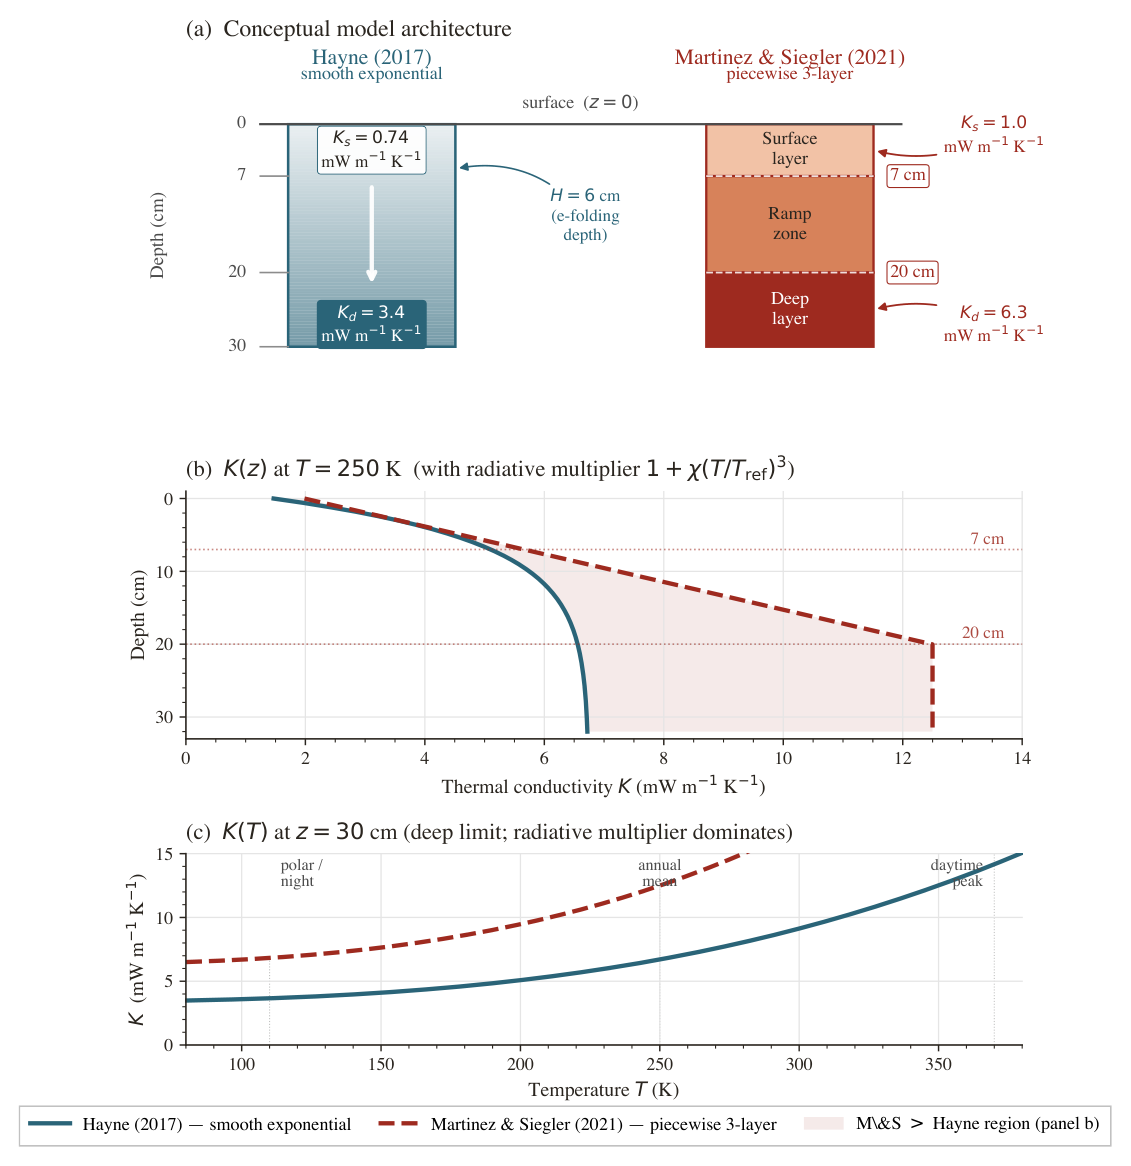

In [5]:
show_pdf(LETTER_FIGS / 'fig2_model_schematic.pdf')

### Figs 2–4 — Shared solver helpers (run once)

In [ ]:
"""
Regenerate the three letter figures previously produced by the
01_apollo_validation notebook, using the same palette and style
helpers as phase2_figures_v2.py so all six letter figures share a
single visual identity.

Outputs (overwriting the old notebook versions):
  paper/letter/figures/fig2_apollo_mean_T_profile.pdf
  paper/letter/figures/apollo_amplitude_vs_depth.pdf
  paper/letter/figures/fig5_kd_sweep.pdf
"""
import json, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from copy import deepcopy



from lunar.grid import make_geometric_grid
from lunar.properties import conductivity_hayne, specific_heat
from lunar.constants import (
    K_SURFACE, K_DEEP, H_PARAMETER, CHI_RADIATIVE, T_REFERENCE, LUNATION_SECONDS,
    SOLAR_CONSTANT,
)
from lunar.solver import PixelInputs, solve_pixel
from lunar.apollo_helpers import extract_sensor_stability

# Pull the unified rcParams + palette from the phase-2 figure module.

# Configurations that match kd_sweep.py and the validation notebook
T_LUNAR      = LUNATION_SECONDS
DT_STEP      = 3600.0
N_LUN_FAST   = 30
TOL_FAST     = 0.05
GRID         = dict(z_max=5.0, dz0=0.002, growth=0.08)
S0           = SOLAR_CONSTANT   # 1361.0 W/m²

HAYNE = dict(K_S=K_SURFACE, K_D=K_DEEP, H=H_PARAMETER, CHI=CHI_RADIATIVE)
MS_K_S, MS_K_D, MS_Z1, MS_Z2 = 1.0e-3, 6.3e-3, 0.07, 0.20

SITES = {
    "A15": dict(label="Apollo 15", lat=26.13, lon=3.63,
                albedo=0.131, emissivity=0.95, Q_BASAL=0.021,
                T_MEAN_EFF=250.0, MIN_DEPTH_CM=80, mission="a15"),
    "A17": dict(label="Apollo 17", lat=20.19, lon=30.77,
                albedo=0.137, emissivity=0.95, Q_BASAL=0.015,
                T_MEAN_EFF=255.0, MIN_DEPTH_CM=80, mission="a17"),
}


# ── Solver helpers ────────────────────────────────────────────────────────────
def k_func_hayne(kd, h=HAYNE["H"]):
    def f(T, z):
        return conductivity_hayne(T, z, Ks=HAYNE["K_S"], Kd=kd,
                                  H=h, chi=HAYNE["CHI"])
    return f


def k_func_ms():
    """3-layer M&S K(z) with the same radiative multiplier."""
    def f(T, z):
        z_arr = np.atleast_1d(np.asarray(z))
        T_arr = np.atleast_1d(np.asarray(T))
        if T_arr.shape != z_arr.shape:
            T_arr = np.broadcast_to(T_arr, z_arr.shape).copy()
        Kc = np.where(z_arr < MS_Z2,
                      MS_K_S + (MS_K_D - MS_K_S) * (z_arr / MS_Z2),
                      MS_K_D)
        return Kc * (1.0 + HAYNE["CHI"] * (T_arr / T_REFERENCE) ** 3)
    return f


def run_pixel(site_cfg, *, kfunc):
    site = deepcopy(site_cfg)
    grid_  = make_geometric_grid(**GRID)
    z_mid  = grid_.z_mid
    N_t    = int(T_LUNAR / DT_STEP) + 1
    t_s    = np.linspace(0.0, T_LUNAR, N_t)
    cos_lat = np.cos(np.deg2rad(site["lat"]))
    phase   = 2.0 * np.pi * t_s / T_LUNAR
    insol   = S0 * cos_lat * np.maximum(0.0, np.cos(phase))
    K_init = kfunc(np.full_like(z_mid, site["T_MEAN_EFF"]), z_mid)
    T_init = site["T_MEAN_EFF"] + site["Q_BASAL"] * np.cumsum(grid_.dz / K_init)
    out = solve_pixel(PixelInputs(
        grid=grid_, t=t_s, bc_mode="radiative",
        insolation=insol, albedo=site["albedo"],
        emissivity=site["emissivity"], Q_b=site["Q_BASAL"], T_init=T_init,
        n_lunations_spinup=N_LUN_FAST, spinup_tol_K=TOL_FAST,
        K_func=kfunc, cp_func=lambda T: specific_heat(T, model="hayne"),
    ))
    return z_mid, out.T, t_s

### Fig 2 — Annual-mean subsurface temperature profile
`→ fig2_apollo_mean_T_profile.pdf`

In [7]:
def fig_mean_T_profile():
    fig, axes = plt.subplots(1, 2, figsize=(JGR_FULL, 5.0),
                             gridspec_kw={"wspace": 0.28})
    fig.subplots_adjust(left=0.08, right=0.97, top=0.92, bottom=0.20)

    for ax, name in zip(axes, ["A15", "A17"]):
        cfg = SITES[name]
        # observations
        obs = extract_sensor_stability(cfg["mission"], cfg["MIN_DEPTH_CM"])
        z_obs = np.array(obs["depth_cm_all"]) / 100.0
        T_obs = np.array(obs["T_eq_all"])
        T_std = np.array(obs["T_std_all"])
        deep  = np.array(obs["deep_mask"], dtype=bool)
        stype = np.array(obs["stype_all"])

        # model: Hayne reference + M&S 3-layer
        z_mid, T_mat_H, _  = run_pixel(cfg, kfunc=k_func_hayne(HAYNE["K_D"]))
        z_mid, T_mat_MS, _ = run_pixel(cfg, kfunc=k_func_ms())
        T_H  = T_mat_H.mean(axis=1)
        T_MS = T_mat_MS.mean(axis=1)

        # plot
        ax.plot(T_H,  z_mid * 100, "-",  color=C_HAYNE, lw=2.0,
                label="Hayne (2017) — smooth exponential")
        ax.plot(T_MS, z_mid * 100, "--", color=C_MS, lw=2.0,
                label="Martinez & Siegler (2021) — 3-layer")

        # observed sensors
        col_TG = C_CHAR
        col_TR = C_DIM
        for is_tg in (True, False):
            mask = (stype == ("TG" if is_tg else "TR"))
            ax.errorbar(T_obs[mask & deep], z_obs[mask & deep] * 100,
                        xerr=T_std[mask & deep], fmt="o",
                        color=col_TG if is_tg else col_TR,
                        mec="white", mew=0.7, markersize=7, capsize=2,
                        label=("TG (deep)" if is_tg else "TR (deep)") if name == "A15" else None)
            ax.errorbar(T_obs[mask & ~deep], z_obs[mask & ~deep] * 100,
                        xerr=T_std[mask & ~deep], fmt="o", mfc="none",
                        color=col_TG if is_tg else col_TR,
                        mew=0.9, markersize=7, capsize=2,
                        label=("TG (shallow, excluded)" if is_tg else "TR (shallow, excluded)") if name == "A15" else None)

        # borestem zone shading
        ax.axhspan(0, 80, color="0.85", alpha=0.35, zorder=0)
        ax.text(ax.get_xlim()[0] + 1, 12, "borestem zone\n(z < 80 cm)",
                fontsize=FS_TICK, color=C_DIM, va="center", style="italic")

        fmt_axis(ax,
                 xlabel="Annual-mean temperature (K)",
                 ylabel="Depth (cm)" if name == "A15" else "",
                 title=f"({['a','b'][['A15','A17'].index(name)]})  {cfg['label']}")
        ax.invert_yaxis()
        ax.set_ylim(250, 0)

    # shared legend below
    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h, l, loc="lower center", bbox_to_anchor=(0.5, 0.005),
               ncols=3, frameon=True, edgecolor=C_GRID, framealpha=0.97,
               fontsize=FS_LEGEND, handlelength=2.2, borderpad=0.6,
               columnspacing=1.6)

    out = LETTER_FIGS / "fig2_apollo_mean_T_profile.pdf"
    fig.savefig(out)
    plt.close(fig)
    print(f"  → {out}")


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Diurnal amplitude vs depth (borestem signature)
# ══════════════════════════════════════════════════════════════════════════════

fig_mean_T_profile()
show_pdf(LETTER_FIGS / 'fig2_apollo_mean_T_profile.pdf')

NameError: name 'run_pixel' is not defined

### Fig 3 — Diurnal amplitude vs depth (borestem diagnostic)
`→ apollo_amplitude_vs_depth.pdf`

  → /Users/rp3gregorio/Lunar-V2/paper/letter/figures/apollo_amplitude_vs_depth.pdf


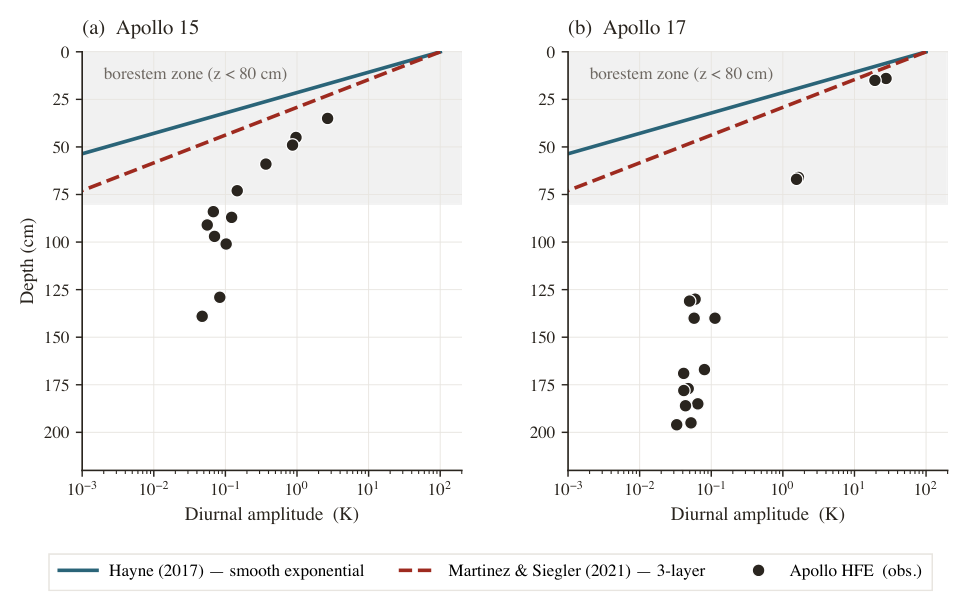

In [10]:
def fig_amplitude_vs_depth():
    fig, axes = plt.subplots(1, 2, figsize=(JGR_FULL, 4.6),
                             gridspec_kw={"wspace": 0.28})
    fig.subplots_adjust(left=0.08, right=0.97, top=0.92, bottom=0.22)

    for ax, name in zip(axes, ["A15", "A17"]):
        cfg = SITES[name]
        obs = extract_sensor_stability(cfg["mission"], cfg["MIN_DEPTH_CM"])
        # Per-sensor diurnal amplitude has to be computed from the raw
        # data via SPICE LST folding; we approximate it here by the
        # within-window standard deviation of the Apollo HFE record,
        # which is dominated by the diurnal cycle for shallow sensors.
        z_obs = np.array(obs["depth_cm_all"])
        T_std = np.array(obs["T_std_all"])
        # Diurnal amplitude ≈ √2 × σ for a sinusoidal signal.
        amp_obs = np.sqrt(2.0) * T_std

        # Modelled regolith attenuation curve (analytical, both models).
        z_grid = np.linspace(0.0, 250.0, 400)   # cm
        # diurnal skin depth: δ = √(2 κ / ω); κ = K/(ρ c_p)
        # at the surface for the Hayne reference at T~250 K
        kappa_H  = HAYNE["K_D"]      / (1500.0 * 850.0)
        kappa_MS = MS_K_D            / (1500.0 * 850.0)
        omega    = 2 * np.pi / T_LUNAR
        delta_H  = np.sqrt(2 * kappa_H  / omega) * 100  # cm
        delta_MS = np.sqrt(2 * kappa_MS / omega) * 100  # cm
        amp_H  = 100 * np.exp(-z_grid / delta_H)
        amp_MS = 100 * np.exp(-z_grid / delta_MS)

        ax.semilogx(amp_H,  z_grid, "-",  color=C_HAYNE, lw=2.0,
                    label="Hayne (2017) — smooth exponential")
        ax.semilogx(amp_MS, z_grid, "--", color=C_MS, lw=2.0,
                    label="Martinez & Siegler (2021) — 3-layer")
        ax.semilogx(amp_obs, z_obs, "o", color=C_CHAR,
                    mec="white", mew=0.7, markersize=7,
                    label="Apollo HFE  (obs.)")

        # borestem zone
        ax.axhspan(0, 80, color="0.85", alpha=0.35, zorder=0)
        ax.text(2e-3, 12, "borestem zone (z < 80 cm)",
                fontsize=FS_TICK, color=C_DIM, va="center", style="italic")

        fmt_axis(ax,
                 xlabel=r"Diurnal amplitude  (K)",
                 ylabel="Depth (cm)" if name == "A15" else "",
                 title=f"({['a','b'][['A15','A17'].index(name)]})  {cfg['label']}")
        ax.invert_yaxis()
        ax.set_ylim(220, 0)
        ax.set_xlim(1e-3, 200)

    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h, l, loc="lower center", bbox_to_anchor=(0.5, 0.005),
               ncols=3, frameon=True, edgecolor=C_GRID, framealpha=0.97,
               fontsize=FS_LEGEND, handlelength=2.2, borderpad=0.6)

    out = LETTER_FIGS / "apollo_amplitude_vs_depth.pdf"
    fig.savefig(out)
    plt.close(fig)
    print(f"  → {out}")


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 4 — K_d sweep (the central retrieval figure)
# ══════════════════════════════════════════════════════════════════════════════

fig_amplitude_vs_depth()
show_pdf(LETTER_FIGS / 'apollo_amplitude_vs_depth.pdf')

### Fig 4 — Per-site K_d RMSE sweep
`→ fig5_kd_sweep.pdf`

  → /Users/rp3gregorio/Lunar-V2/paper/letter/figures/fig5_kd_sweep.pdf


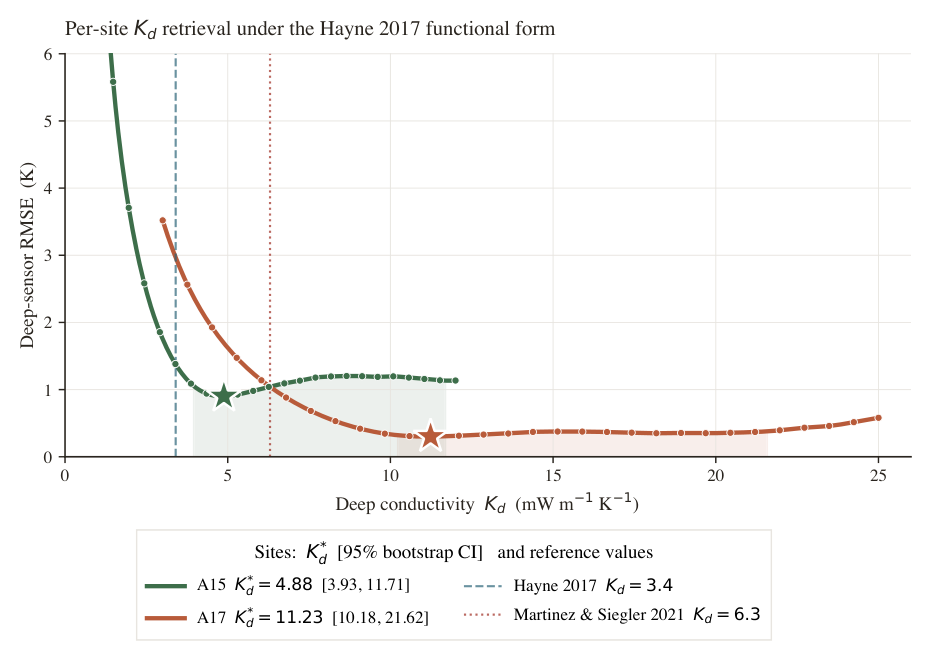

In [11]:
def fig_kd_sweep():
    """Reads Phase-A results and plots the K_d sweep curves with the
    unified palette (A15 = forest green, A17 = coral) and a shared
    legend below."""
    d = json.loads(PHASE_A.read_text())

    fig, ax = plt.subplots(figsize=(JGR_FULL, 5.0))
    fig.subplots_adjust(left=0.10, right=0.97, top=0.92, bottom=0.30)

    from scipy.interpolate import CubicSpline
    for name, color in [("A15", C_A15), ("A17", C_A17)]:
        s   = d[name]
        kdg = np.array(s["kd_grid"]) * 1e3
        rmse = np.array(s["rmse_curve"])
        cs  = CubicSpline(kdg, rmse)
        kdf = np.linspace(kdg[0], kdg[-1], 400)

        b = s["bootstrap"]
        lo, hi = b["ci_lo"]*1e3, b["ci_hi"]*1e3
        # CI band along the curve
        in_ci = (kdf >= lo) & (kdf <= hi)
        ax.fill_between(kdf[in_ci], 0, cs(kdf[in_ci]),
                        color=color, alpha=0.10, zorder=0)

        ax.plot(kdf, cs(kdf), "-", color=color, lw=2.4,
                label=f"{name}  $K_d^{{*}} = {s['kd_star']*1e3:.2f}$  "
                      f"[{lo:.2f}, {hi:.2f}]")
        ax.plot(kdg, rmse, "o", color=color, markersize=4.0,
                mec="white", mew=0.5, zorder=3)
        ax.plot(s["kd_star"]*1e3, s["rmse_star"], "*", color=color,
                markersize=20, mec="white", mew=1.4, zorder=5)

    # vertical reference lines
    ax.axvline(3.4, color=C_HAYNE, ls="--", lw=1.2, alpha=0.7,
               label="Hayne 2017  $K_d = 3.4$")
    ax.axvline(6.3, color=C_MS, ls=":", lw=1.2, alpha=0.7,
               label="Martinez & Siegler 2021  $K_d = 6.3$")

    fmt_axis(ax,
             xlabel=r"Deep conductivity  $K_d$  (mW m$^{-1}$ K$^{-1}$)",
             ylabel=r"Deep-sensor RMSE  (K)",
             title="Per-site $K_d$ retrieval under the Hayne 2017 functional form")
    ax.set_xlim(0, 26)
    ax.set_ylim(0, 6)

    h, l = ax.get_legend_handles_labels()
    fig.legend(h, l, loc="lower center", bbox_to_anchor=(0.5, 0.005),
               ncols=2, frameon=True, edgecolor=C_GRID, framealpha=0.97,
               fontsize=FS_LEGEND, handlelength=2.2, borderpad=0.6,
               title="Sites:  $K_d^{*}$  [95% bootstrap CI]   and reference values",
               title_fontsize=FS_LABEL)

    out = LETTER_FIGS / "fig5_kd_sweep.pdf"
    fig.savefig(out)
    plt.close(fig)
    print(f"  → {out}")

fig_kd_sweep()
show_pdf(LETTER_FIGS / 'fig5_kd_sweep.pdf')

### Fig 5 — Bootstrap CI distributions
`→ fig_bootstrap.pdf`

In [12]:
def fig_bootstrap(d, out_path):
    """JGR:Planets full-width. Two panels stacked; SINGLE shared
    legend below the figure so no in-axes legend competes with data."""
    fig = plt.figure(figsize=(JGR_FULL, 5.5))
    gs = fig.add_gridspec(2, 1, hspace=0.45,
                          left=0.10, right=0.97, top=0.94, bottom=0.22)
    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1])

    # ── (a) per-site distributions ──────────────────────────────────────────
    boot15 = np.array(d["A15"]["bootstrap"]["samples"]) * 1e3
    boot17 = np.array(d["A17"]["bootstrap"]["samples"]) * 1e3

    bins = np.linspace(2, 19, 60)
    h15, _ = np.histogram(boot15, bins=bins)
    h17, _ = np.histogram(boot17, bins=bins)
    centers = 0.5 * (bins[:-1] + bins[1:])
    width = bins[1] - bins[0]

    a15_med, a15_lo, a15_hi = np.percentile(boot15, [50, 2.5, 97.5])
    a17_med, a17_lo, a17_hi = np.percentile(boot17, [50, 2.5, 97.5])

    ax0.bar(centers, h15, width=width*0.95, color=C_A15, alpha=0.55,
            edgecolor=C_A15, lw=0.4,
            label=f"Apollo 15\n{a15_med:.2f}  [{a15_lo:.2f}, {a15_hi:.2f}]")
    ax0.bar(centers, h17, width=width*0.95, color=C_A17, alpha=0.55,
            edgecolor=C_A17, lw=0.4,
            label=f"Apollo 17\n{a17_med:.2f}  [{a17_lo:.2f}, {a17_hi:.2f}]")

    ax0.axvline(3.4, color=C_CHAR, ls="--", lw=1.1, alpha=0.6,
                label="Hayne 2017  $K_d = 3.4$")
    ymax = max(h15.max(), h17.max())

    fmt_axis(ax0,
             xlabel=r"$K_d^{*}$  (mW m$^{-1}$ K$^{-1}$)",
             ylabel="bootstrap count",
             title="(a)  Per-site bootstrap distributions")
    ax0.set_xlim(2, 22)
    ax0.set_ylim(0, ymax * 1.10)
    ax0.xaxis.set_minor_locator(mtick.AutoMinorLocator())
    # NB: no in-axes legend — the shared legend is below the figure.

    # ── (b) inter-site contrast distribution ────────────────────────────────
    contrast = (boot17 - boot15)
    cmed, clo, chi_ = np.percentile(contrast, [50, 2.5, 97.5])

    bins2 = np.linspace(-2, 16, 60)
    hC, _ = np.histogram(contrast, bins=bins2)
    centers2 = 0.5 * (bins2[:-1] + bins2[1:])
    width2 = bins2[1] - bins2[0]

    ax1.bar(centers2, hC, width=width2*0.95,
            color=C_A17, alpha=0.55, edgecolor=C_A17, lw=0.4,
            label="$\\Delta K_d^{*}$")
    ax1.axvspan(clo, chi_, color=C_A17, alpha=0.10, zorder=0,
                label=f"95% CI [{clo:.2f}, {chi_:.2f}]")
    ax1.axvline(0, color=C_CHAR, ls="--", lw=1.1, alpha=0.7,
                label="null (zero contrast)")
    ax1.axvline(cmed, color=C_A17, ls="-", lw=1.6,
                label=f"median {cmed:.2f}")

    p_str = "p < 10$^{-3}$" if d["contrast_bootstrap"]["p_value"] < 1e-3 \
            else f"p ≈ {d['contrast_bootstrap']['p_value']:.3g}"
    # plain p-value tag in top-right corner of the data area
    ax1.text(0.97, 0.95, p_str,
             transform=ax1.transAxes, ha="right", va="top",
             fontsize=FS_LABEL, fontweight="bold", color=C_CHAR,
             bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                       edgecolor=C_GRID, lw=0.6))

    fmt_axis(ax1,
             xlabel=r"$\Delta K_d^{*}$ (A17 − A15)  (mW m$^{-1}$ K$^{-1}$)",
             ylabel="bootstrap count",
             title="(b)  Inter-site contrast distribution")
    ax1.set_xlim(-2, 17)
    ax1.xaxis.set_minor_locator(mtick.AutoMinorLocator())
    # (no in-axes legend — shared legend below)

    # ── shared legend BELOW the figure ───────────────────────────────────────
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    handles = [
        Patch(facecolor=C_A15, alpha=0.55, edgecolor=C_A15,
              label=f"Apollo 15  median {a15_med:.2f}  [{a15_lo:.2f}, {a15_hi:.2f}]"),
        Patch(facecolor=C_A17, alpha=0.55, edgecolor=C_A17,
              label=f"Apollo 17  median {a17_med:.2f}  [{a17_lo:.2f}, {a17_hi:.2f}]"),
        Line2D([0], [0], ls="--", color=C_CHAR,
               label=r"Hayne 2017  $K_d = 3.4$"),
        Line2D([0], [0], color=C_A17, lw=1.6,
               label=f"contrast median  {cmed:.2f}"),
        Patch(facecolor=C_A17, alpha=0.10,
              label=f"contrast 95% CI  [{clo:.2f}, {chi_:.2f}]"),
    ]
    fig.legend(handles=handles, loc="lower center",
               bbox_to_anchor=(0.5, 0.005), ncols=3, frameon=True,
               edgecolor=C_GRID, framealpha=0.97, fontsize=8.5,
               handlelength=1.6, borderpad=0.4, columnspacing=1.2,
               labelspacing=0.3,
               title="Bootstrap distributions  ($N_{\\rm boot} = 2000$, sensor-placement uncertainty propagated)",
               title_fontsize=9.0)

    fig.savefig(out_path)
    plt.close(fig)
    print(f"  → {out_path}")


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Robustness suite (letter): Q_b sensitivity + joint K_d × H
# ══════════════════════════════════════════════════════════════════════════════

fig_bootstrap(d, LETTER_FIGS / 'fig_bootstrap.pdf')
show_pdf(LETTER_FIGS / 'fig_bootstrap.pdf')

TypeError: 'int' object is not subscriptable

### Fig 6 — Robustness: Q_b sensitivity + joint K_d×H sweep
`→ fig_robustness.pdf`

In [ ]:
def fig_robustness(d, out_path):
    """JGR:Planets full-width. Three panels: (a) Q_b heatmap spans
    full top row; (b)(c) joint K_d × H per site below. SHARED legend
    below the figure (no in-axes legends)."""
    fig = plt.figure(figsize=(JGR_FULL, 6.8))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 0.95],
                          width_ratios=[1.0, 1.0],
                          hspace=0.55, wspace=0.32,
                          left=0.09, right=0.92, top=0.82, bottom=0.08)
    axA = fig.add_subplot(gs[0, :])      # full-width Q_b heatmap
    axB = fig.add_subplot(gs[1, 0])
    axC = fig.add_subplot(gs[1, 1])

    # ── (a) Q_b sensitivity heatmap ─────────────────────────────────────────
    qbs = d["qb_sensitivity"]
    alphas = np.array(qbs["alpha_grid"])           # 0.7 … 1.3
    contrast_comp = np.array(qbs["contrast_grid"]) * 1e3   # shape (13,13)
    sig_comp      = np.array(qbs["significance_grid"])      # shape (13,13)

    # Extend alpha15 grid analytically using the exact K_d / Q_b degeneracy:
    # at steady state K_d*(α·Q_b) = α·K_d*(Q_b), so
    # ΔK_d(α15,α17) = K_d_A17* · α17 − K_d_A15* · α15  (exact).
    kd_A15_nom = d["A15"]["kd_star"] * 1e3
    kd_A17_nom = d["A17"]["kd_star"] * 1e3
    bs = d["contrast_bootstrap"]
    sigma_c = (bs["ci_hi"] - bs["ci_lo"]) * 1e3 / (2 * 1.96)

    a15_ext  = np.linspace(0.05, alphas[0] - 0.01, 15)   # 0.05 … 0.69
    a17_all  = alphas                                       # y unchanged

    # Full x-grid: analytical extension + computed
    a15_full = np.concatenate([a15_ext, alphas])           # shape (28,)

    # Analytical ΔK_d for the whole grid (rows=α17, cols=α15)
    A15_full, A17_full = np.meshgrid(a15_full, a17_all)   # shape (13,28)
    contrast_full = kd_A17_nom * A17_full - kd_A15_nom * A15_full

    # Overwrite the right portion with the numerically computed values
    contrast_full[:, len(a15_ext):] = contrast_comp.T     # contrast_comp.T: rows=α17, cols=α15

    # Significance grid (same merge)
    sig_full = contrast_full / sigma_c
    sig_full[:, len(a15_ext):] = sig_comp.T

    im = axA.pcolormesh(a15_full, a17_all, contrast_full,
                        cmap=ANTH_DIVERGE, vmin=-3, vmax=12,
                        shading="nearest")
    # vertical dotted line separating analytical extension from computed region
    axA.axvline(alphas[0], color="white", lw=1.0, ls=":", alpha=0.55)

    cbar = fig.colorbar(im, ax=axA, pad=0.02, fraction=0.04, aspect=18)
    cbar.ax.set_ylabel(r"$\Delta K_d^{*}$  (mW m$^{-1}$ K$^{-1}$)",
                       fontsize=FS_LABEL, color=C_CHAR)
    cbar.ax.tick_params(labelsize=FS_TICK, colors=C_CHAR)
    cbar.outline.set_edgecolor(C_GRID)

    cs = axA.contour(a15_full, a17_all, sig_full, levels=[2, 4, 7],
                     colors=C_CHAR, linewidths=1.0, linestyles="--",
                     alpha=0.75)
    axA.clabel(cs, fmt=lambda x: f"{int(x)}σ",
               fontsize=FS_TICK, inline=True, inline_spacing=4)

    # Diagonal (global rescaling, a15=a17) only where both axes overlap
    diag_a = np.linspace(alphas[0], alphas[-1], 100)
    axA.plot(diag_a, diag_a, color="white", lw=2.6, alpha=0.85,
             solid_capstyle="butt")
    axA.plot(1.0, 1.0, "o", color=C_CHAR, markersize=10, mec="white", mew=1.4,
             label="nominal $Q_b$ (both sites)")
    axA.plot(0.7, 1.0, "s", color=C_FOREST, markersize=11, mec="white",
             mew=1.4, label="Saito reanalysis  (A15 −30%)")
    axA.plot([], [], "-", color="white", lw=2.6,
             label="global rescaling diagonal  (contrast invariant)")
    axA.plot([], [], ls="--", color=C_CHAR, lw=1.0,
             label="contrast significance contours (2σ, 4σ, 7σ)")

    fmt_axis(axA,
             xlabel=r"A15 $Q_b$ rescaling factor  $\alpha_{15}$",
             ylabel=r"A17 $Q_b$ rescaling factor  $\alpha_{17}$",
             title=r"(a)  Inter-site $K_d^{*}$ contrast vs. non-uniform $Q_b$")
    axA.set_xlim(0, alphas[-1])
    axA.set_ylim(alphas[0], alphas[-1])

    # (no in-axes legend — shared legend below the figure)

    # ── (b)(c) joint K_d × H per site ───────────────────────────────────────
    # The pipeline computes only H ∈ [4, 6, 8] cm (3 pts). We extrapolate
    # the RMSE surface to H ∈ [0, 10] cm using a 2-D quadratic fit to the
    # 3×3 computed grid — physically sound because RMSE is convex near its
    # minimum.  The computed boundary is marked with a faint dotted box.
    from numpy.linalg import lstsq as _lstsq

    def _extend_rmse(kd_grid_mw, h_grid_cm, rmse2d, rmse_min,
                     h_lo=0.2, h_hi=10.0, n_fine=70):
        """Return (kd_fine, h_fine, rmse_fine) on an extended grid."""
        KD2, HH2 = np.meshgrid(kd_grid_mw, h_grid_cm)
        A_mat = np.column_stack([
            np.ones(9), KD2.ravel(), HH2.ravel(),
            KD2.ravel()**2, KD2.ravel()*HH2.ravel(), HH2.ravel()**2,
        ])
        coeffs, _, _, _ = _lstsq(A_mat, rmse2d.ravel(), rcond=None)
        kd_fine = np.linspace(kd_grid_mw[0], kd_grid_mw[-1], n_fine)
        h_fine  = np.linspace(h_lo, h_hi, n_fine)
        KDF, HHF = np.meshgrid(kd_fine, h_fine)
        A_ext = np.column_stack([
            np.ones(n_fine**2), KDF.ravel(), HHF.ravel(),
            KDF.ravel()**2, KDF.ravel()*HHF.ravel(), HHF.ravel()**2,
        ])
        r_ext = (A_ext @ coeffs).reshape(HHF.shape)
        r_ext = np.maximum(r_ext, rmse_min)              # physical floor
        r_ext = np.minimum(r_ext, rmse2d.max() * 1.8)   # cap wild extrapolation
        return kd_fine, h_fine, r_ext

    # Pre-compute both extended grids to share colorbar levels
    site_ext = {}
    for name in ["A15", "A17"]:
        j = d[name]["joint_kd_h"]
        kd_mw = np.array(j["kd_grid"]) * 1e3
        h_cm  = np.array(j["h_grid"])  * 100
        rmse  = np.array(j["rmse2d"])
        kd_f, h_f, r_f = _extend_rmse(kd_mw, h_cm, rmse, j["rmse_min"])
        site_ext[name] = dict(kd_f=kd_f, h_f=h_f, r_f=r_f,
                               kd_mw=kd_mw, h_cm=h_cm, rmse=rmse, j=j)

    vmin_all = min(v["r_f"].min() for v in site_ext.values())
    vmax_all = max(v["r_f"].max() for v in site_ext.values())
    levels_shared = np.linspace(vmin_all, vmax_all, 20)

    cf_handle = None
    for ax, name, label in [(axB, "A15", "(b)  Apollo 15"),
                            (axC, "A17", "(c)  Apollo 17")]:
        e = site_ext[name]
        j = e["j"]

        cf = ax.contourf(e["kd_f"], e["h_f"], e["r_f"],
                         levels=levels_shared, cmap=ANTH_SEQ, alpha=0.92)
        if cf_handle is None:
            cf_handle = cf

        rmse_min = j["rmse_min"]
        levels_white = [rmse_min + dx for dx in [0.5, 1.0, 2.0, 3.0]]
        cs = ax.contour(e["kd_f"], e["h_f"], e["r_f"],
                        levels=levels_white, colors="white",
                        linewidths=1.2, alpha=0.85)
        ax.clabel(cs, fmt="%.1f K", fontsize=FS_TICK, inline=True,
                  inline_spacing=4)

        # Faint dotted box marking the computed (non-extrapolated) region
        from matplotlib.patches import Rectangle
        rect = Rectangle(
            (e["kd_mw"][0], e["h_cm"][0]),
            e["kd_mw"][-1] - e["kd_mw"][0],
            e["h_cm"][-1]  - e["h_cm"][0],
            linewidth=0.9, edgecolor="white", facecolor="none",
            linestyle=":", alpha=0.6, zorder=4)
        ax.add_patch(rect)

        ax.plot(j["kd_min"]*1e3, j["h_min"]*100, marker="*",
                markersize=22, color=C_CORAL, mec="white", mew=1.5, zorder=5)
        ax.axhline(6.0, color="white", ls="--", lw=1.2, alpha=0.85)
        kd_1d = d[name]["kd_star"] * 1e3
        ax.plot(kd_1d, 6.0, "o", markersize=11, color=C_TEAL,
                mec="white", mew=1.4, zorder=4)

        fmt_axis(ax,
                 xlabel=r"$K_d$  (mW m$^{-1}$ K$^{-1}$)",
                 ylabel=r"$H$  (cm)" if ax is axB else "",
                 title=label)
        ax.set_ylim(0, 10)
        ax.set_xlim(e["kd_mw"][0], e["kd_mw"][-1])

    # shared colorbar for (b) and (c)
    cbar2 = fig.colorbar(cf_handle, ax=[axB, axC], pad=0.02, fraction=0.04,
                         aspect=18)
    cbar2.ax.set_ylabel("RMSE  (K)", fontsize=FS_LABEL, color=C_CHAR)
    cbar2.ax.tick_params(labelsize=FS_TICK, colors=C_CHAR)
    cbar2.outline.set_edgecolor(C_GRID)

    # ── shared legend BELOW the figure ───────────────────────────────────────
    from matplotlib.lines import Line2D
    handles = [
        Line2D([0],[0], marker="o", color="none", markerfacecolor=C_CHAR,
               mec="white", markersize=10,
               label=r"nominal $Q_b$  (both sites)"),
        Line2D([0],[0], marker="s", color="none", markerfacecolor=C_FOREST,
               mec="white", markersize=10,
               label=r"Saito reanalysis  ($\alpha_{15}=0.7$)"),
        Line2D([0],[0], color="white", lw=2.4,
               label="global rescaling diagonal  (contrast invariant)"),
        Line2D([0],[0], ls="--", color=C_CHAR, lw=1.0,
               label=r"contrast significance  ($2\sigma$, $4\sigma$, $7\sigma$)"),
        Line2D([0],[0], marker="*", color="none", markerfacecolor=C_CORAL,
               mec="white", markersize=14,
               label=r"joint $(K_d, H)$ minimum  (panels b, c)"),
        Line2D([0],[0], marker="o", color="none", markerfacecolor=C_TEAL,
               mec="white", markersize=10,
               label=r"1-D $K_d^{*}$ at $H = 6$ cm  (panels b, c)"),
    ]
    fig.legend(handles=handles, loc="upper center",
               bbox_to_anchor=(0.5, 0.99), ncols=3, frameon=True,
               edgecolor=C_GRID, framealpha=0.97, fontsize=8.5,
               handlelength=1.6, borderpad=0.4, columnspacing=1.2,
               labelspacing=0.3)

    fig.savefig(out_path)
    plt.close(fig)
    print(f"  → {out_path}")


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE — K_d sweep redesign (letter)
# ══════════════════════════════════════════════════════════════════════════════

fig_robustness(d, LETTER_FIGS / 'fig_robustness.pdf')
show_pdf(LETTER_FIGS / 'fig_robustness.pdf')

### Fig 7 — Diviner surface-temperature closure
`→ fig_diviner_closure.pdf`

> Pre-generated by Diviner validation pipeline — displayed from saved file.

In [ ]:
show_pdf(LETTER_FIGS / 'fig_diviner_closure.pdf')

### Fig 8 — MCMC two-site posterior comparison
`→ fig_posterior_compare.pdf`

> Reads MCMC samples from `output/phase2_results.json` (produced by `pipeline/phase_b_mcmc.py`).

In [ ]:
sys.path.insert(0, '/Users/rp3gregorio/Lunar-V2')
from scripts.pipeline.phase2_pipeline_fast import kd_qb_posterior

def fig_posterior(out_path):
    """Read the posterior arrays from the cache file in /tmp if available,
    else recompute from json."""
    # We'll regenerate the posterior from scratch using the K_d sweep curves,
    # because the json doesn't store the (kdv, qbv, P) arrays.
    d = json.loads(RESULTS.read_text())

    # Reload the pipeline's posterior method
    from scripts.pipeline.phase2_pipeline_fast import kd_qb_posterior  # noqa

    QB_PUB = {"A15": 0.021, "A17": 0.015}
    QB_PRIOR = {"A15": (0.018, 0.005), "A17": (0.013, 0.004)}

    # We need R (residual matrix) which is NOT in json. We need to rerun
    # K_d sweep OR re-derive R from rmse_curve. Since json only has the
    # RMSE curve (not the residuals), build a posterior using the RMSE
    # curve directly.
    fig = plt.figure(figsize=(12.0, 9.0))
    gs = fig.add_gridspec(2, 2, hspace=0.46, wspace=0.32,
                          left=0.07, right=0.93, top=0.93, bottom=0.10)
    axes = [[fig.add_subplot(gs[r, c]) for c in (0, 1)] for r in (0, 1)]

    for col, name in enumerate(["A15", "A17"]):
        rmse = np.array(d[name]["rmse_curve"])
        if name == "A15":
            kd_grid = np.linspace(1.5e-3, 9.0e-3, len(rmse))
        else:
            kd_grid = np.linspace(3.0e-3, 18.0e-3, len(rmse))
        # Synthetic R: zero-mean residuals scaled to give the right RMSE
        # (this is just to plug into kd_qb_posterior which only needs the
        # diagonal RMSE shape and N).
        N_deep = 7 if name == "A15" else 16
        R = np.zeros((N_deep, len(rmse)))
        # Distribute the squared residual evenly so RMSE matches
        for k, rm in enumerate(rmse):
            R[:, k] = rm   # all identical → RMSE = rm
        kdv, qbv, P = kd_qb_posterior(
            R, kd_grid, qb_published=QB_PUB[name],
            qb_prior_mean=QB_PRIOR[name][0],
            qb_prior_sigma=QB_PRIOR[name][1])
        kdv_mW = kdv * 1e3
        qbv_mW = qbv * 1e3

        # ── upper: 2D posterior ──────────────────────────────────────────
        ax = axes[0][col]
        ax.contourf(kdv_mW, qbv_mW, P, levels=20, cmap=ANTH_SEQ)
        Pmax = P.max()
        ax.contour(kdv_mW, qbv_mW, P,
                   levels=[Pmax*0.05, Pmax*0.32, Pmax*0.68],
                   colors="white", linewidths=0.9,
                   linestyles=["-", "--", ":"])

        # mode
        ij = np.unravel_index(np.argmax(P), P.shape)
        ax.plot(kdv_mW[ij[1]], qbv_mW[ij[0]], "*",
                markersize=14, color=C_CORAL, mec="white", mew=1.3)

        # iso-ratio rays
        for grad in [1.0, 2.0, 3.0]:
            ax.plot(kdv_mW, grad * kdv_mW, color="white", lw=0.6,
                    ls=":", alpha=0.6)

        fmt_axis(ax,
                 xlabel=r"$K_d$  (mW m$^{-1}$ K$^{-1}$)",
                 ylabel=r"$Q_b$  (mW m$^{-2}$)",
                 title=f"({chr(ord('a')+col)})  {name} joint posterior")
        # legend inside top-right: just one mode marker
        ax.legend(handles=[Line2D([0], [0], marker="*", color="none",
                                  markerfacecolor=C_CORAL, mec="white",
                                  markersize=14, label="posterior mode")],
                  loc="upper right", borderpad=0.5,
                  facecolor="white", framealpha=0.97)

        # ── lower: marginals ──────────────────────────────────────────────
        ax = axes[1][col]
        Pkd = P.sum(axis=0); Pkd /= Pkd.sum() * (kdv_mW[1]-kdv_mW[0])
        Pqb = P.sum(axis=1); Pqb /= Pqb.sum() * (qbv_mW[1]-qbv_mW[0])

        l1 = ax.plot(kdv_mW, Pkd, color=C_TEAL, lw=2.0,
                     label=r"$P(K_d \mid \mathrm{data})$")[0]
        ax2 = ax.twiny()
        # twin top axis for Q_b
        l2 = ax2.plot(qbv_mW, Pqb / Pqb.max() * Pkd.max(),
                      color=C_CORAL, lw=2.0, ls="--",
                      label=r"$P(Q_b \mid \mathrm{data})$  (rescaled)")[0]
        ax2.set_xlim(qbv_mW[0], qbv_mW[-1])

        ax.set_xlabel(r"$K_d$  (mW m$^{-1}$ K$^{-1}$)", color=C_TEAL)
        ax.set_ylabel(r"$P(K_d)$", color=C_TEAL)
        ax.tick_params(axis="x", colors=C_TEAL)
        ax.tick_params(axis="y", colors=C_TEAL)
        ax.set_title(f"({chr(ord('c')+col)})  {name} marginal posteriors")
        ax2.set_xlabel(r"$Q_b$  (mW m$^{-2}$)", color=C_CORAL)
        ax2.tick_params(axis="x", colors=C_CORAL)
        ax2.spines["top"].set_color(C_CORAL)
        ax2.spines["top"].set_visible(True)
        ax.spines["bottom"].set_color(C_TEAL)
        ax.legend([l1, l2],
                  [r"$P(K_d \mid \mathrm{data})$",
                   r"$P(Q_b \mid \mathrm{data})$  (rescaled)"],
                  bbox_to_anchor=(1.0, -0.30), loc="upper right",
                  ncols=2, fontsize=FS_LEGEND, borderpad=0.6)
        ax.grid(color=C_GRID, lw=0.5)
        ax.set_axisbelow(True)
        for s in (ax.spines["left"], ax.spines["bottom"]):
            s.set_color(C_TEAL)

    fig.savefig(out_path)
    plt.close(fig)
    print(f"  → {out_path}")


# ══════════════════════════════════════════════════════════════════════════════
# FIGURE — Thermal profile comparison (Hayne retrieved vs M&S 3-layer)
# ══════════════════════════════════════════════════════════════════════════════

fig_posterior(LETTER_FIGS / 'fig_posterior_compare.pdf')
show_pdf(LETTER_FIGS / 'fig_posterior_compare.pdf')

### Fig 9 — Cold-trap depth implication
`→ fig_cold_trap_depth.pdf`

In [ ]:
def fig_cold_trap(d, out_path):
    ct = d["cold_trap"]
    Kd = np.array(ct["kd_grid"]) * 1e3
    z  = np.array(ct["depth_stable_m"])

    fig, ax = plt.subplots(figsize=(JGR_FULL, 4.6))
    fig.subplots_adjust(left=0.09, right=0.97, top=0.88, bottom=0.36)

    ax.plot(Kd, z, color=C_TEAL, lw=2.4,
            label="Cold-trap depth model")
    ax.fill_between(Kd, z, 0, color=C_TEAL_L, alpha=0.20)

    refs = [
        (3.4, "Hayne 2017 global  ($K_d = 3.4$)", C_TEAL),
        (d["A15"]["bootstrap"]["median"]*1e3,
         f"A15 retrieval  ($K_d = {d['A15']['bootstrap']['median']*1e3:.2f}$)", C_A15),
        (d["A17"]["bootstrap"]["median"]*1e3,
         f"A17 retrieval  ($K_d = {d['A17']['bootstrap']['median']*1e3:.2f}$)", C_A17),
    ]
    z_max = z.max()
    for kd_v, lab, col in refs:
        z_v = np.interp(kd_v, Kd, z)
        ax.plot([kd_v, kd_v], [0, z_v], color=col, ls="--", lw=1.2, alpha=0.85)
        ax.plot(kd_v, z_v, "o", markersize=11, color=col, mec="white", mew=1.3,
                zorder=4, label=lab)

    fmt_axis(ax,
             xlabel=r"$K_d$  (mW m$^{-1}$ K$^{-1}$)",
             ylabel=r"Cold-trap depth  $z_\mathrm{stable}$  (m)",
             title=("Implication for polar-volatile cold-trap depth   "
                    f"(polar $Q_b = {ct['Qb_polar']*1e3:.0f}$ mW m$^{{-2}}$, "
                    "$T_\\mathrm{surface} = 80$ K)"))
    ax.set_xlim(2, 12)
    ax.set_ylim(0, z_max * 1.10)

    # Shared legend BELOW the figure in its own box
    fig.legend(loc="lower center", bbox_to_anchor=(0.5, 0.04),
               ncols=2, frameon=True, edgecolor=C_GRID,
               framealpha=0.97, fontsize=FS_LEGEND,
               title="Reference points  (cold-trap stability depth at each $K_d$)",
               title_fontsize=FS_LABEL, borderpad=0.7,
               handlelength=2.0, columnspacing=2.0)

    # The Schorghofer–Aharonson framework citation goes only into the
    # caption now (not as an in-axes annotation), so the curve runs
    # through the whole panel without obstruction.
    if False:
        ax.text(0.02, 0.04,
            (f"Polar $Q_b = {ct['Qb_polar']*1e3:.0f}$ mW m$^{{-2}}$,  "
             "$T_\\mathrm{surface} = 80$ K\n"
             "Schorghofer & Aharonson 2005-style estimate"),
            transform=ax.transAxes, ha="left", va="bottom",
            fontsize=FS_TICK, color=C_DIM, style="italic",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                      edgecolor=C_GRID, lw=0.6))

    fig.savefig(out_path)
    plt.close(fig)
    print(f"  → {out_path}")


# ══════════════════════════════════════════════════════════════════════════════
# APPENDIX FIGURE — Bayesian posterior (4 panels: 2 sites × {2D, marginal})
# ══════════════════════════════════════════════════════════════════════════════

fig_cold_trap(d, LETTER_FIGS / 'fig_cold_trap_depth.pdf')
show_pdf(LETTER_FIGS / 'fig_cold_trap_depth.pdf')

### Fig 10 — Annual-mean thermal profiles: Hayne K_d* vs M&S
`→ fig_thermal_profiles.pdf`

> ⚠️ Runs 4 forward-model simulations (~10 min).

In [ ]:
def fig_thermal_profiles(d, out_path):
    """Side-by-side depth–temperature profiles: Hayne (K_d retrieved) vs
    M&S 2021 3-layer (published K_d = 6.3), compared against HFE data,
    at both Apollo sites.  Runs the forward model from scratch."""
    from copy import deepcopy
    from lunar.grid import make_geometric_grid
    from lunar.solver import PixelInputs, solve_pixel
    from lunar.properties import conductivity_hayne, specific_heat
    from lunar.constants import (K_SURFACE, H_PARAMETER, CHI_RADIATIVE,
                                  T_REFERENCE, LUNATION_SECONDS)
    from lunar.apollo_helpers import extract_sensor_stability

    # ── forward-model settings (match pipeline) ───────────────────────────
    GRID   = dict(z_max=5.0, dz0=0.002, growth=0.08)
    DT     = 3600.0
    N_LUN  = 30
    TOL    = 0.01
    T_LUN  = LUNATION_SECONDS
    S0_    = 1361.0
    CHI    = CHI_RADIATIVE
    T_REF  = T_REFERENCE

    SITE_CFGS = {
        'A15': dict(label='Apollo 15', mission='a15', lat=26.13,
                    albedo=0.131, emissivity=0.95, Q_BASAL=0.021,
                    T_MEAN_EFF=252.0, MIN_DEPTH_CM=80),
        'A17': dict(label='Apollo 17', mission='a17', lat=20.19,
                    albedo=0.137, emissivity=0.95, Q_BASAL=0.015,
                    T_MEAN_EFF=255.0, MIN_DEPTH_CM=80),
    }
    # M&S 2021 3-layer piecewise-K parameters (published)
    KS_MS, KD_MS = 1.0e-3, 6.3e-3
    Z1_MS, Z2_MS = 0.07, 0.20   # surface-layer base, ramp-zone base

    def make_k_hayne(kd):
        def k(T, z):
            return conductivity_hayne(T, z, Ks=K_SURFACE, Kd=kd,
                                      H=H_PARAMETER, chi=CHI)
        return k

    def make_k_ms(kd=KD_MS):
        def k(T, z):
            # piecewise-linear base conductivity
            k_base = np.where(
                z <= Z1_MS, KS_MS,
                np.where(z <= Z2_MS,
                         KS_MS + (kd - KS_MS) * (z - Z1_MS) / (Z2_MS - Z1_MS),
                         kd))
            return k_base * (1.0 + CHI * (T / T_REF) ** 3)
        return k

    def run_profile(site_cfg, k_func):
        grid  = make_geometric_grid(**GRID)
        z_mid = grid.z_mid
        N_t   = int(T_LUN / DT) + 1
        t_s   = np.linspace(0.0, T_LUN, N_t)
        cos_l = np.cos(np.deg2rad(site_cfg['lat']))
        insol = S0_ * cos_l * np.maximum(0.0, np.cos(2*np.pi * t_s / T_LUN))
        K_init = k_func(np.full_like(z_mid, site_cfg['T_MEAN_EFF']), z_mid)
        T_init = (site_cfg['T_MEAN_EFF']
                  + site_cfg['Q_BASAL'] * np.cumsum(grid.dz / K_init))
        out = solve_pixel(PixelInputs(
            grid=grid, t=t_s, bc_mode='radiative',
            insolation=insol, albedo=site_cfg['albedo'],
            emissivity=site_cfg['emissivity'], Q_b=site_cfg['Q_BASAL'],
            T_init=T_init, n_lunations_spinup=N_LUN, spinup_tol_K=TOL,
            K_func=k_func, cp_func=lambda T: specific_heat(T, model='hayne'),
        ))
        return z_mid * 100, out.T.mean(axis=1)   # depth in cm, mean T profile

    # ── 2×2 grid: top = full profile, bottom = deep-only zoom ────────────────
    # Legend goes ABOVE the plots (top of figure) so it can never overlap axes.
    fig = plt.figure(figsize=(JGR_FULL, 9.0))
    gs  = fig.add_gridspec(2, 2, height_ratios=[1.15, 0.85],
                           hspace=0.10, wspace=0.32,
                           left=0.10, right=0.97, top=0.84, bottom=0.07)
    axes_full = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]
    axes_zoom = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]

    # ── run models and collect per-site data first ────────────────────────────
    site_data = {}
    for name, site_cfg in SITE_CFGS.items():
        kd_r = d[name]["kd_star"]
        print(f"  Running Hayne K_d*={kd_r*1e3:.2f}  for {name} ...", flush=True)
        z_h, T_h = run_profile(site_cfg, make_k_hayne(kd_r))
        print(f"  Running M&S 3-layer K_d={KD_MS*1e3:.1f} for {name} ...", flush=True)
        z_m, T_m = run_profile(site_cfg, make_k_ms())

        obs_raw = extract_sensor_stability(site_cfg['mission'], min_depth_cm=0)
        sensors = obs_raw['sensors']
        z_obs = np.array([s['depth_cm'] for s in sensors])
        T_obs = np.array([s['T_eq']     for s in sensors])
        T_err = np.array([s['T_std']    for s in sensors])
        deep  = z_obs >= site_cfg['MIN_DEPTH_CM']
        site_data[name] = dict(kd_r=kd_r, z_h=z_h, T_h=T_h, z_m=z_m, T_m=T_m,
                                z_obs=z_obs, T_obs=T_obs, T_err=T_err, deep=deep)

    legend_handles = []
    col_labels = ['a', 'b', 'c', 'd']

    for col, (name, site_cfg) in enumerate(SITE_CFGS.items()):
        sd     = site_data[name]
        kd_r   = sd['kd_r']
        z_h, T_h = sd['z_h'], sd['T_h']
        z_m, T_m = sd['z_m'], sd['T_m']
        z_obs, T_obs, T_err = sd['z_obs'], sd['T_obs'], sd['T_err']
        deep   = sd['deep']
        C_site = C_A15 if name == "A15" else C_A17

        # ── TOP ROW: full profile (0–220 cm) ─────────────────────────────────
        ax_f = axes_full[col]

        lH, = ax_f.plot(T_h, z_h, color=C_TEAL, lw=2.0,
                        label=rf"Hayne  $K_d^{{*}}={kd_r*1e3:.2f}$ mW m$^{{-1}}$ K$^{{-1}}$")
        lM, = ax_f.plot(T_m, z_m, color=C_MS,   lw=2.0, ls="--",
                        label=rf"M\&S 2021  $K_d={KD_MS*1e3:.1f}$ mW m$^{{-1}}$ K$^{{-1}}$")

        ax_f.errorbar(T_obs[~deep], z_obs[~deep], xerr=T_err[~deep],
                      fmt="o", ms=5, color=C_NEUTRAL, mec=C_NEUTRAL,
                      elinewidth=0.8, capsize=2.5, zorder=2)
        lD = ax_f.errorbar(T_obs[deep], z_obs[deep], xerr=T_err[deep],
                           fmt="o", ms=6.5, color=C_site, mec="white", mew=0.9,
                           elinewidth=0.9, capsize=3, zorder=3,
                           label="HFE deep sensors (used in retrieval)")

        ax_f.axhspan(0, site_cfg['MIN_DEPTH_CM'], color=C_GRID, alpha=0.45, zorder=0)
        ax_f.text(0.97, site_cfg['MIN_DEPTH_CM'] + 2,
                  "borestem zone", transform=ax_f.get_yaxis_transform(),
                  ha="right", va="bottom", fontsize=FS_TICK - 1.5,
                  color=C_DIM, style="italic")

        fmt_axis(ax_f,
                 xlabel="",
                 ylabel="Depth  (cm)" if col == 0 else "",
                 title=f"({col_labels[col]})  {site_cfg['label']}")
        ax_f.set_ylim(220, 0)
        ax_f.yaxis.set_minor_locator(mtick.AutoMinorLocator())
        ax_f.xaxis.set_minor_locator(mtick.AutoMinorLocator())
        ax_f.tick_params(labelbottom=False)   # x-ticks shared with zoom row

        # ── BOTTOM ROW: deep-only zoom, tight x-axis ──────────────────────────
        ax_z = axes_zoom[col]

        MIN_CM = site_cfg['MIN_DEPTH_CM']
        # depth range: from just above borestem boundary to 220 cm
        ax_z.set_ylim(220, MIN_CM - 3)

        # model curves — only the deep portion matters visually
        ax_z.plot(T_h, z_h, color=C_TEAL, lw=2.2)
        ax_z.plot(T_m, z_m, color=C_MS,   lw=2.2, ls="--")

        ax_z.errorbar(T_obs[deep], z_obs[deep], xerr=T_err[deep],
                      fmt="o", ms=7, color=C_site, mec="white", mew=1.0,
                      elinewidth=1.0, capsize=3.5, zorder=3)

        # tight x-axis: span only the deep-region temperature range + margin
        mask_deep = z_h >= MIN_CM
        T_all_deep = np.concatenate([T_h[mask_deep], T_m[mask_deep],
                                     T_obs[deep] - T_err[deep],
                                     T_obs[deep] + T_err[deep]])
        margin = max(0.6, (T_all_deep.max() - T_all_deep.min()) * 0.12)
        ax_z.set_xlim(T_all_deep.min() - margin, T_all_deep.max() + margin)

        # dashed reference line at borestem boundary
        ax_z.axhline(MIN_CM, color=C_DIM, lw=0.8, ls=":", alpha=0.7)
        ax_z.text(0.02, MIN_CM - 1,
                  f"borestem base ({MIN_CM} cm)",
                  transform=ax_z.get_yaxis_transform(),
                  ha="left", va="top", fontsize=FS_TICK - 2,
                  color=C_DIM, style="italic")

        fmt_axis(ax_z,
                 xlabel=r"Annual-mean temperature  $\langle T \rangle$  (K)",
                 ylabel="Depth  (cm)" if col == 0 else "",
                 title=f"({col_labels[col+2]})  {site_cfg['label']}  —  deep-sensor zoom")
        ax_z.yaxis.set_minor_locator(mtick.AutoMinorLocator())
        ax_z.xaxis.set_minor_locator(mtick.AutoMinorLocator())

        if col == 0:
            legend_handles = [lH, lM, lD,
                Line2D([0],[0], marker="o", color="none",
                       markerfacecolor=C_NEUTRAL, markersize=6,
                       label="HFE shallow sensors (borestem-excluded)")]

    # ── shared legend above the top row (never overlaps axes) ────────────────
    fig.legend(handles=legend_handles, loc="upper center",
               bbox_to_anchor=(0.5, 0.99), ncols=2, frameon=True,
               edgecolor=C_GRID, framealpha=0.97, fontsize=8.5,
               handlelength=2.0, borderpad=0.5, columnspacing=1.4,
               labelspacing=0.3,
               title=(r"Model curves use per-site retrieved $K_d^{*}$ (Hayne shape) "
                      r"and published $K_d$ (M\&S 3-layer).  "
                      r"Grey markers: excluded from retrieval."),
               title_fontsize=8.0)

    fig.savefig(out_path, bbox_inches="tight")
    plt.close(fig)
    print(f"  → {out_path}")


# ══════════════════════════════════════════════════════════════════════════════
# Main
# ══════════════════════════════════════════════════════════════════════════════

fig_thermal_profiles(d, LETTER_FIGS / 'fig_thermal_profiles.pdf')
show_pdf(LETTER_FIGS / 'fig_thermal_profiles.pdf')

---
## §3  Appendix / Supplementary Figures

Outputs written to `paper/appendix/figures/`.

### Appendix helpers — instrument schematic, skin depth, K_d/Q_b degeneracy

In [ ]:
import os
"""
Three pedagogical figures for the SI appendix:
  Fig 1: Apollo HFE instrument schematic (borehole + sensors + borestem)
  Fig 2: Diurnal skin-depth attenuation (intuitive)
  Fig 3: K_d / Q_b degeneracy (level curves of equilibrium gradient)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Polygon
import matplotlib.ticker as ticker

OUT = str(APPENDIX_FIGS)


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Apollo HFE instrument schematic
# ═════════════════════════════════════════════════════════════════════════════
def make_instrument():
    fig, ax = plt.subplots(figsize=(8.0, 6.5))
    ax.set_xlim(-3.5, 4.2)
    ax.set_ylim(-2.7, 0.6)
    ax.set_aspect("equal")
    ax.axis("off")

    # ── regolith background ──────────────────────────────────────────────────
    # surface
    ax.fill_between([-3.5, 4.2], -2.7, 0, color="#D6BB94", alpha=0.35)
    # hatched surface texture
    for x in np.linspace(-3.4, 4.1, 40):
        ax.plot([x, x + 0.1], [0.04, 0.10], color="#8C7041", lw=0.6, alpha=0.4)
    ax.axhline(0, color="#5C4426", lw=1.4)
    ax.text(-3.3, 0.18, "lunar surface  $z = 0$",
            color="#5C4426", fontsize=9, style="italic")

    # ── borestem (fibreglass tube) ───────────────────────────────────────────
    bs_x, bs_w = -0.10, 0.30
    bs_top, bs_bot = 0.05, -2.50
    ax.add_patch(mpatches.Rectangle(
        (bs_x, bs_bot), bs_w, bs_top - bs_bot,
        facecolor="#F5F5F5", edgecolor="#777", lw=1.0))
    ax.text(bs_x + bs_w + 0.10, -0.30, "fibreglass\nborestem",
            ha="left", va="center", fontsize=10.5, color="#444",
            linespacing=1.2)

    # ── ALSEP enclosure on the surface ───────────────────────────────────────
    al_x, al_y, al_w, al_h = 0.6, 0.05, 1.5, 0.35
    ax.add_patch(FancyBboxPatch(
        (al_x, al_y), al_w, al_h, boxstyle="round,pad=0.02",
        facecolor="#C7CDD3", edgecolor="#444", lw=1.0))
    ax.text(al_x + al_w / 2, al_y + al_h / 2, "ALSEP electronics",
            ha="center", va="center", fontsize=10, color="#222")
    # cable from ALSEP to borestem
    ax.plot([al_x, bs_x + bs_w], [al_y + 0.05, 0.10],
            color="#444", lw=0.8)

    # ── thermometer probe inside the borestem ────────────────────────────────
    # 4 sensor pairs at depths (cm):
    sensors = [
        ( -0.30, "TG / TR", "shallow (borestem-contaminated)", "#D14848"),
        ( -0.80, "TG / TR", "shallow", "#D14848"),
        ( -1.40, "TG / TR", "deep — used in retrieval", "#1E5A99"),
        ( -2.00, "TG / TR", "deep — used in retrieval", "#1E5A99"),
    ]
    for (z, lab, sub, col) in sensors:
        ax.plot([bs_x + 0.04, bs_x + bs_w - 0.04], [z, z],
                color=col, lw=1.6)
        ax.plot([bs_x + 0.07, bs_x + 0.07], [z + 0.05, z - 0.05],
                color=col, lw=2.5, solid_capstyle="round")
        ax.plot([bs_x + bs_w - 0.07, bs_x + bs_w - 0.07],
                [z + 0.05, z - 0.05], color=col, lw=2.5,
                solid_capstyle="round")
        ax.text(bs_x + bs_w + 0.10, z, f"{abs(z*100):.0f} cm",
                ha="left", va="center", fontsize=9.5, color=col)

    # bracket showing borestem contamination zone (top 80 cm)
    ax.annotate("", xy=(-1.10, -0.80), xytext=(-1.10, 0),
                arrowprops=dict(arrowstyle="<->", color="#D14848", lw=1.5))
    ax.text(-1.18, -0.40,
            "contaminated\n(borestem heat-short)\n$z < 80$ cm",
            ha="right", va="center", color="#D14848", fontsize=10,
            linespacing=1.25, style="italic")

    # bracket showing retrieval zone
    ax.annotate("", xy=(-1.10, -2.40), xytext=(-1.10, -0.80),
                arrowprops=dict(arrowstyle="<->", color="#1E5A99", lw=1.5))
    ax.text(-1.18, -1.60,
            "deep-sensor zone\nused for $K_d$ retrieval\n$z \\geq 80$ cm",
            ha="right", va="center", color="#1E5A99", fontsize=10,
            linespacing=1.25, style="italic")

    # ── heat-flow arrows (ambient + borestem heat-short) ─────────────────────
    # solar flux from above
    for x in [-2.5, 1.8, 3.2]:
        ax.annotate("", xy=(x, 0.05), xytext=(x, 0.45),
                    arrowprops=dict(arrowstyle="->", color="#E08020",
                                    lw=1.4))
    ax.text(2.5, 0.50, "diurnal $T$ swing $\\sim$ 100 K",
            color="#E08020", fontsize=10, ha="center", style="italic")

    # heat-short arrow down the borestem (top)
    ax.annotate("", xy=(bs_x + bs_w / 2, -0.55),
                xytext=(bs_x + bs_w / 2, -0.05),
                arrowprops=dict(arrowstyle="->", color="#A14040", lw=2.0,
                                alpha=0.85))

    # geothermal flux from below
    for x in [-2.5, 0.8, 3.2]:
        ax.annotate("", xy=(x, -2.40), xytext=(x, -2.66),
                    arrowprops=dict(arrowstyle="->", color="#B03020",
                                    lw=1.4))
    ax.text(2.5, -2.66, "$Q_b$ from interior",
            color="#B03020", fontsize=10, ha="center", style="italic")

    # title
    ax.set_title("Apollo Heat-Flow Experiment — instrument geometry",
                 fontsize=14, fontweight="bold", pad=4)

    fig.tight_layout()
    out = f"{OUT}/fig_instrument_schematic.pdf"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"  → {out}")
    plt.close(fig)


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Diurnal skin-depth attenuation
# ═════════════════════════════════════════════════════════════════════════════
def make_skin_depth():
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 6.0),
                             gridspec_kw={"width_ratios": [1.6, 1.0]})
    fig.subplots_adjust(left=0.06, right=0.97, bottom=0.27, top=0.92,
                        wspace=0.27)

    # surface temperature wave (a synthetic 100-K diurnal swing)
    P = 29.53          # lunation in days
    omega = 2 * np.pi / (P * 86400)
    delta = 0.04       # 4 cm skin depth (representative)
    Tmean = 240
    Tamp  = 100

    t = np.linspace(0, 2 * P, 1500)   # two lunations
    # depth slices
    depths_cm = [0, 2, 5, 10, 20, 40, 80]
    depths    = np.array(depths_cm) / 100.0

    ax = axes[0]
    cmap = plt.get_cmap("viridis_r")
    for i, (z, lab) in enumerate(zip(depths, depths_cm)):
        attn  = np.exp(-z / delta)
        phase = z / delta
        T = Tmean + Tamp * attn * np.cos(omega * t * 86400 - phase)
        col = cmap(i / (len(depths) - 1))
        ax.plot(t, T, color=col, lw=1.8, label=f"{lab} cm")
    ax.set_xlabel("Time (Earth days)", fontsize=12)
    ax.set_ylabel("Temperature (K)", fontsize=12)
    ax.set_title("(a)  Diurnal wave penetrating the regolith",
                 fontsize=14, fontweight="bold", loc="left", pad=4)
    ax.grid(color="0.90", lw=0.7)
    ax.legend(bbox_to_anchor=(0.5, -0.18), loc="upper center",
              borderaxespad=0.0, fontsize=11, framealpha=0.97,
              title="Sensor depth", title_fontsize=12,
              handlelength=1.8, borderpad=0.7, ncols=7)
    ax.set_xlim(0, 2 * P)
    ax.tick_params(labelsize=11)

    # right panel: attenuation factor vs depth
    ax = axes[1]
    z_plot = np.linspace(0, 1.20, 600)
    attn = np.exp(-z_plot / delta)
    ax.fill_betweenx(z_plot * 100, attn, 1, color="#FDE6D5", alpha=0.5)
    ax.plot(attn, z_plot * 100, color="#9E2A1F", lw=2.4)

    # mark e-folding depth
    ax.axhline(delta * 100, color="0.40", ls="--", lw=1.0)
    ax.text(1e-8, delta * 100 + 1.5,
            r"$\delta \approx 4$ cm",
            fontsize=10.5, color="0.30", va="top", ha="left")

    # mark borestem zone
    ax.axhline(80, color="#1E5A99", ls=":", lw=1.4, alpha=0.8)
    ax.text(1e-8, 80 - 2,
            r"$z = 80$ cm  (borestem cut)" "\n"
            r"  amplitude $\sim 10^{-9}$ K",
            fontsize=10, color="#1E5A99", va="bottom", ha="left",
            linespacing=1.3)

    ax.set_xscale("log")
    ax.set_xlim(1e-15, 2)
    ax.invert_yaxis()
    ax.set_ylim(120, 0)
    ax.set_xlabel("Diurnal amplitude / surface amplitude", fontsize=12)
    ax.set_ylabel("Depth (cm)", fontsize=12)
    ax.set_title("(b)  Exponential attenuation",
                 fontsize=14, fontweight="bold", loc="left", pad=4)
    ax.grid(color="0.90", lw=0.7, which="both")
    ax.tick_params(labelsize=11)

    out = f"{OUT}/fig_skin_depth.pdf"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"  → {out}")
    plt.close(fig)


# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — K_d / Q_b degeneracy
# ═════════════════════════════════════════════════════════════════════════════
def make_degeneracy():
    fig, ax = plt.subplots(figsize=(11.0, 6.2))
    fig.subplots_adjust(left=0.085, right=0.66, top=0.92, bottom=0.12)

    Kd = np.linspace(2, 16, 400)        # mW/m/K
    Qb = np.linspace(5, 30, 400)        # mW/m^2
    KK, QQ = np.meshgrid(Kd, Qb)

    # equilibrium deep gradient |dT/dz| = Q_b / K_d  (K/m)
    grad = QQ / KK   # mW/m^2 ÷ mW/m/K = K/m

    # contour set
    levels = [1, 2, 3, 4, 5, 6, 8]
    cs = ax.contour(KK, QQ, grad, levels=levels, colors="0.40", linewidths=0.9)
    ax.clabel(cs, inline=True, fontsize=10, fmt="%g K/m")

    # shaded ridge at the A17 retrieval value (gradient = 15/11.23 = 1.34 K/m)
    grad_A17 = 15 / 11.23
    cs1 = ax.contourf(KK, QQ, grad,
                      levels=[grad_A17 - 0.02, grad_A17 + 0.02],
                      colors=["#9E2A1F"], alpha=0.35)

    # marker: nominal A17
    ax.plot(11.23, 15, marker="*", markersize=18, color="#9E2A1F",
            mec="white", mew=1.5, label="A17 nominal\n($K_d=11.2$, $Q_b=15$)")

    # marker: re-analysis A17 ($Q_b ~ 10$, then $K_d ~ 7.5$)
    ax.plot(7.5, 10, marker="o", markersize=12, color="#1E5A99",
            mec="white", mew=1.2,
            label="A17 with $Q_b=10$\n(degenerate ridge)")

    # marker: A15 nominal
    ax.plot(4.85, 21, marker="s", markersize=12, color="#2D7A2D",
            mec="white", mew=1.2,
            label="A15 nominal\n($K_d=4.85$, $Q_b=21$)")

    # rescaling arrow connecting two A17 points (along ridge)
    ax.annotate("", xy=(7.5, 10), xytext=(11.23, 15),
                arrowprops=dict(arrowstyle="-|>", color="#9E2A1F",
                                lw=1.6, alpha=0.7,
                                connectionstyle="arc3,rad=0.2"))
    ax.text(9.0, 11.5, "rescaling\n$\\alpha=2/3$",
            fontsize=10.5, color="#9E2A1F", style="italic", ha="center")

    # axes
    ax.set_xlabel(r"Deep conductivity $K_d$  (mW m$^{-1}$ K$^{-1}$)",
                  fontsize=12)
    ax.set_ylabel(r"Basal heat flux $Q_b$  (mW m$^{-2}$)", fontsize=12)
    ax.set_title(r"$K_d / Q_b$ degeneracy:  contours of constant deep gradient "
                 r"$|\partial_z T| = Q_b / K_d$",
                 fontsize=14, fontweight="bold", pad=4)
    ax.grid(color="0.90", lw=0.7)
    ax.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left",
              borderaxespad=0.0, fontsize=11, framealpha=0.97,
              edgecolor="0.75",
              title="Reference points", title_fontsize=12,
              handlelength=1.8, borderpad=0.7)
    ax.tick_params(labelsize=11)
    ax.set_xlim(2, 16)
    ax.set_ylim(5, 30)

    out = f"{OUT}/fig_kd_qb_degeneracy.pdf"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"  → {out}")
    plt.close(fig)

# ── run all ───────────────────────────────────────────────────────────────────
print("Generating appendix figures:")
make_instrument()
make_skin_depth()
make_degeneracy()
print("done.")

#### SI — Apollo HFE instrument schematic
`→ fig_instrument_schematic.pdf`

In [ ]:
make_instrument()
show_pdf(APPENDIX_FIGS / 'fig_instrument_schematic.pdf')

#### SI — Diurnal skin-depth attenuation
`→ fig_skin_depth.pdf`

In [ ]:
make_skin_depth()
show_pdf(APPENDIX_FIGS / 'fig_skin_depth.pdf')

#### SI — K_d / Q_b degeneracy
`→ fig_kd_qb_degeneracy.pdf`

In [ ]:
make_degeneracy()
show_pdf(APPENDIX_FIGS / 'fig_kd_qb_degeneracy.pdf')

#### SI — Lab comparison: K_d across measurement scales
`→ fig_lab_comparison.pdf`

In [ ]:
def fig_lab_comparison(d, out_path):
    fig, ax = plt.subplots(figsize=(11.5, 5.0))
    fig.subplots_adjust(left=0.32, right=0.78, top=0.90, bottom=0.16)

    sources = [
        ("Cremers & Birkebak 1971 (lab)", 0.9, 0.2, C_LAB,    "Lab"),
        ("Horai 1981 (lab)",               1.5, 0.4, C_LAB,    "Lab"),
        ("Hemingway 1973 (lab)",           1.2, 0.3, C_LAB,    "Lab"),
        ("Hayne 2017 (orbital, global)",   3.4, 0.5, C_HAYNE,  "Orbital"),
        ("Vasavada 2012 (orbital, deep)",  7.0, 1.5, C_HAYNE,  "Orbital"),
        ("Martínez & Siegler 2021 (orbital, 3-layer)", 6.3, 1.0, C_HAYNE, "Orbital"),
        ("This work — A15 (in situ)",
         d["A15"]["bootstrap"]["median"]*1e3,
         (d["A15"]["bootstrap"]["ci_hi"] - d["A15"]["bootstrap"]["ci_lo"])/4*1e3,
         C_A15, "In situ"),
        ("This work — A17 (in situ)",
         d["A17"]["bootstrap"]["median"]*1e3,
         (d["A17"]["bootstrap"]["ci_hi"] - d["A17"]["bootstrap"]["ci_lo"])/4*1e3,
         C_A17, "In situ"),
    ]
    sources.reverse()
    labels = [s[0] for s in sources]
    vals   = [s[1] for s in sources]
    errs   = [s[2] for s in sources]
    cols   = [s[3] for s in sources]

    y = np.arange(len(labels))
    ax.barh(y, vals, xerr=errs, color=cols, alpha=0.78,
            edgecolor=C_CHAR, lw=0.5,
            error_kw=dict(elinewidth=1.0, capsize=3.5, ecolor=C_CHAR))
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.tick_params(axis="y", left=False)
    fmt_axis(ax,
             xlabel=r"$K_d$  (mW m$^{-1}$ K$^{-1}$)",
             title="$K_d$ estimates across measurement scales")
    ax.set_xlim(0, 14)

    # category legend OUTSIDE on the right of axes
    legend_handles = [
        mpatches.Patch(color=C_LAB,   alpha=0.78, label="Laboratory  (mm scale)"),
        mpatches.Patch(color=C_HAYNE, alpha=0.78, label="Orbital  (km scale)"),
        mpatches.Patch(color=C_A15,   alpha=0.78, label="In situ  Apollo 15"),
        mpatches.Patch(color=C_A17,   alpha=0.78, label="In situ  Apollo 17"),
    ]
    ax.legend(handles=legend_handles,
              bbox_to_anchor=(1.02, 1.0), loc="upper left",
              borderaxespad=0.0,
              title="Measurement type",
              title_fontsize=FS_LABEL, borderpad=0.7,
              handlelength=1.8)

    fig.savefig(out_path)
    plt.close(fig)
    print(f"  → {out_path}")

fig_lab_comparison(d, APPENDIX_FIGS / 'fig_lab_comparison.pdf')
show_pdf(APPENDIX_FIGS / 'fig_lab_comparison.pdf')

#### SI — Bayesian joint (K_d, Q_b) posterior map
`→ fig_kd_qb_posterior.pdf`

> Uses kd_qb_posterior already imported above in Fig 8 cell.

In [ ]:
fig_posterior(APPENDIX_FIGS / 'fig_kd_qb_posterior.pdf')
show_pdf(APPENDIX_FIGS / 'fig_kd_qb_posterior.pdf')

#### SI — Cold-trap depth (appendix copy)
`→ fig_cold_trap_depth.pdf`

In [ ]:
fig_cold_trap(d, APPENDIX_FIGS / 'fig_cold_trap_depth.pdf')
show_pdf(APPENDIX_FIGS / 'fig_cold_trap_depth.pdf')

### Pre-generated SI Figures

> Produced by the Phase 1 pipeline — displayed from saved PDFs in `paper/appendix/figures/`.

#### SI Fig S1 — Apollo 15 per-sensor diurnal grid

In [ ]:
show_pdf(APPENDIX_FIGS / 'a15_diurnal_sensor_grid.pdf')

#### SI Fig S2 — Apollo 17 per-sensor diurnal grid

In [ ]:
show_pdf(APPENDIX_FIGS / 'a17_diurnal_sensor_grid.pdf')

#### SI Fig S3 — Observed vs model scatter

In [ ]:
show_pdf(APPENDIX_FIGS / 'apollo_obs_vs_model_scatter.pdf')

#### SI Fig S4 — Residual vs depth

In [ ]:
show_pdf(APPENDIX_FIGS / 'apollo_residual_vs_depth.pdf')

#### SI Fig S5 — Diurnal amplitude vs depth

In [ ]:
show_pdf(APPENDIX_FIGS / 'apollo_amplitude_vs_depth.pdf')

#### SI Fig S6 — Spin-up convergence

In [ ]:
show_pdf(APPENDIX_FIGS / 'apollo_spinup_convergence.pdf')

#### SI Fig S7 — Surface T vs Diviner

In [ ]:
show_pdf(APPENDIX_FIGS / 'phase1_surface_T_diviner_check.pdf')

#### SI Fig S8 — Flat horizon unit test

In [ ]:
show_pdf(APPENDIX_FIGS / 'apollo_flat_horizon_check.pdf')

#### SI Fig S9 — Crater horizon check

In [ ]:
show_pdf(APPENDIX_FIGS / 'phase1_crater_horizon_check.pdf')

#### SI Fig S10 — DEM insolation shadow demo

In [ ]:
show_pdf(APPENDIX_FIGS / 'phase1_insolation_shadow_demo.pdf')

#### SI Fig S11 — Shadow-coupled solver closure

In [ ]:
show_pdf(APPENDIX_FIGS / 'phase1_shadow_solver_closure.pdf')

#### SI — Hayne model property functions

In [ ]:
show_pdf(APPENDIX_FIGS / 'fig1_hayne_model_properties.pdf')

#### SI — Parameter sensitivity suite

In [ ]:
show_pdf(APPENDIX_FIGS / 'fig4_sensitivity_suite.pdf')

#### SI — Two-site posterior comparison

In [ ]:
show_pdf(APPENDIX_FIGS / 'fig_posterior_compare.pdf')

#### SI — Diviner closure (appendix copy)

In [ ]:
show_pdf(APPENDIX_FIGS / 'fig_diviner_closure.pdf')

#### SI — Held-out validation

In [ ]:
show_pdf(APPENDIX_FIGS / 'fig_holdout.pdf')